# Bioinformatics and Systems Biology (BSB) - Exam Assignment

**Student:** Ilenia Gulino  
**Inspiring paper:** *Cell type-specific transcriptomics identifies neddylation as a novel therapeutic target in multiple sclerosis* (Brain, 2021, doi:10.1093/brain/awaa421)  
**Dataset:** GSE137143 - CD4+ T cells - Treatment-naive MS vs Healthy control

This notebook reproduces a **scaled-down** version of the paper's CD4+ T-cell analysis and then performs the network-medicine analysis.

- **Part 1:** QC -> Salmon quantification -> Differential Expression (DEA) -> gene/pathway enrichment.
- **Part 2:** STRING PPI network -> central nodes -> community detection -> DrugBank drug targets -> drug-disease network proximity.

Design: **8 samples** = 4 MS (treatment-naive) + 4 Healthy Control, balanced by sex (2F/2M per group) and age-matched.



## Executive summary

**Pipeline.** fastp QC/trim -> Salmon gene-level quantification (GENCODE v28, transcriptome-only
index, `--geneMap`) -> **sample-level QC / outlier control** -> PyDESeq2 DEA (`~ sex + condition`)
-> GSEA + ORA enrichment -> STRING physical PPI -> centrality / Louvain communities -> drug-disease
proximity.

**Key findings.**
- **QC:** 2 x 151 bp paired-end; adapter read-through (Illumina TruSeq, ~26-37% of reads); light
  fastp trimming; Salmon mapping 37-46% (transcriptome-only index).
- **Sample QC (important):** one initially-selected sample (SRR10089503) was a CD4+ library
  **with a strong myeloid/monocyte-like expression profile** (high LYZ/CD14/S100A9) incompatible with the
  other CD4 libraries; it was excluded and **replaced by SRR10089494**, restoring the balanced
  cohort.
- **DEA:** 44 DEGs at padj<0.05 (25 also |log2FC|>=1: 8 up / 17 down); no myeloid-dominated profile remains.
- **Enrichment:** GSEA shows **translation / ribosome biogenesis up** in MS and **interferon /
  IL-8 / NK-immunity down**, with a secondary, weaker protein-ubiquitination signal.
- **Comparison with the paper:** NAE1 is directionally concordant and nominally significant (p~0.005) but **not FDR-significant** (padj~0.39);
  only a broad ubiquitin/E3-ligase hint, directionally compatible with - but not specific for - neddylation.
- **Network:** the FDR-DEG **primary** physical PPI is small and fragmented (reported with
  all nodes and degree-zero isolates); a **relaxed network is analysed only as a
  sensitivity** and is centred on **chemokine / NK-cytotoxic** genes. DrugBank-target proximity on a
  fixed STRING physical interactome is **not significant** for any of the three drugs.

## 1. Environment and configuration

In [1]:
from IPython.display import display
from pathlib import Path
import os, sys, subprocess, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Paths (notebook is assumed to live in MS_CD4/notebooks/) ----
PROJECT   = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA      = PROJECT / 'data'
RAW_FASTQ = DATA / 'raw_fastq'
TRIMMED   = DATA / 'fastq_trimmed'      # trimmed paired-end FASTQ files
REF       = DATA / 'reference'          # GENCODE v28
META      = DATA / 'metadata'
IDX       = DATA / 'salmon_index_v112_utf8'   # transcriptome-only Salmon index (no decoy)
QUANT     = DATA / 'salmon_quants'      # Salmon gene-level quantification outputs, one folder per sample_id (=SRR run)

RESULTS  = PROJECT / 'results'
QC       = RESULTS / 'qc'
DEA      = RESULTS / 'dea'
ENRICH   = RESULTS / 'enrichment'
NET      = RESULTS / 'network'
STATE_FILE = RESULTS / 'pipeline_state.json'
for d in [DEA, ENRICH, NET]:
    d.mkdir(parents=True, exist_ok=True)

THREADS = 4             # conservative thread count for local execution
SEED = 42
np.random.seed(SEED)

def pipeline_state() -> dict:
    return json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}

print('PROJECT   =', PROJECT)
print('RAW_FASTQ =', RAW_FASTQ, '(exists:', RAW_FASTQ.exists(), ')')
print('IDX       =', IDX, '(built:', (IDX/"info.json").exists(), ')')
print('pipeline_state.json steps done:', sum(v == 'done' for v in pipeline_state().values()))

PROJECT   = E:\MS_CD4
RAW_FASTQ = E:\MS_CD4\data\raw_fastq (exists: True )
IDX       = E:\MS_CD4\data\salmon_index_v112_utf8 (built: True )
pipeline_state.json steps done: 18


In [2]:
# ---- Docker helper: run the tools (salmon / fastp / multiqc) from the notebook ----
# All command-line steps below run INSIDE the project's `mscd4-bioinfo:latest` image
# (salmon 1.12.0, fastp 0.20.1, multiqc 1.25.2), with the project mounted at /project.
# The notebook executes the required command-line tools directly through Docker. Existing outputs
# are reused when available so completed steps are not repeated unnecessarily.
DOCKER_IMAGE = 'mscd4-bioinfo:latest'

def docker_run(args, log_name=None, echo=True):
    """Run `args` (a list) inside the project Docker image. Paths inside the container are
    under /project (e.g. /project/data/..., /project/results/...). Streams output live."""
    cmd = ['docker', 'run', '--rm',
           '-v', f'{PROJECT}:/project', '-w', '/project',
           DOCKER_IMAGE] + [str(a) for a in args]
    if echo:
        print('$ docker run --rm -v <PROJECT>:/project -w /project', DOCKER_IMAGE, ' '.join(str(a) for a in args))
    # Force UTF-8 decoding: MultiQC/salmon emit non-cp1252 chars (emoji/spinner) which would
    # otherwise crash the default Windows codec and leave proc.stdout = None.
    proc = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8', errors='replace')
    out = (proc.stdout or '') + (proc.stderr or '')
    if log_name:
        (PROJECT / 'logs').mkdir(exist_ok=True)
        (PROJECT / 'logs' / log_name).write_text(out, encoding='utf-8')
    if proc.returncode != 0:
        print(out[-3000:])
        raise RuntimeError(f'Docker command failed (exit {proc.returncode}): {" ".join(args[:2])} ...')
    return out

def mark_state(step, key):
    st = pipeline_state(); st[f'{step}.{key}'] = 'done'
    STATE_FILE.parent.mkdir(parents=True, exist_ok=True)
    STATE_FILE.write_text(json.dumps(st, indent=2, sort_keys=True))

# The CLI tools (salmon/fastp/multiqc/fastqc) run inside the Docker image; the QC and quantification
# cells below are idempotent and invoke Docker only when an output is missing. Tool versions are
# recorded in the final reproducibility cell (no Docker query is made here).

## Part 1 - Task 0: Dataset, metadata review and sample selection

**Dataset.** GSE137143 (the inspiring paper's series) profiles FACS-sorted immune populations
(CD4+ T cells, CD8+ T cells, CD14+ monocytes) from **treatment-naive MS patients** and
**healthy controls**. I first downloaded the **complete GEO metadata** for the whole series -
`GSE137143_family.soft.gz` - which describes **all samples** (one GSM per sorted population per
donor), and parsed the per-sample characteristics (disease state, sex, age, cell type, subtype,
EDSS, ...) into a table.

**Professor's selection criteria.** From this pool I had to pick **8 CD4+ T-cell samples**:
**4 treatment-naive MS vs 4 healthy controls**, balanced **2 females + 2 males per group** and
**age-matched**. Treatment status is encoded in the GEO sample **title** ("Treatment naive MS
patients ..." vs "Healthy controls ..."), because every MS donor in this series is
treatment-naive by design.

**Outcome.** Below I (1) parse the full metadata, (2) apply the criteria to get the eligible
candidate pool, and (3) record/verify my final balanced pick. The 8 chosen samples - with the
SRA **run accessions** used for the FASTQ download - are stored in `data/metadata/samples.csv`,
which every downstream step consumes.

In [3]:
# --- Parse the full GEO SOFT metadata (all samples in GSE137143) ---
import gzip
soft = META / 'GSE137143_family.soft.gz'   # complete series metadata, downloaded from GEO

def parse_geo_soft(path):
    """One row per sample (GSM): the title + every 'key: value' Sample_characteristics field."""
    rows, cur = [], None
    with gzip.open(path, 'rt', encoding='utf-8', errors='replace') as fh:
        for line in fh:
            line = line.rstrip('\n')
            if line.startswith('^SAMPLE'):
                if cur: rows.append(cur)
                cur = {'gsm': line.split('=', 1)[1].strip()}
            elif cur is not None and line.startswith('!Sample_title'):
                cur['title'] = line.split('=', 1)[1].strip()
            elif cur is not None and line.startswith('!Sample_characteristics_ch1') and ':' in line:
                k, v = line.split('=', 1)[1].split(':', 1)
                cur[k.strip()] = v.strip()
        if cur: rows.append(cur)
    return pd.DataFrame(rows)

meta_all = parse_geo_soft(soft)
print('Parsed GEO SOFT:', meta_all.shape[0], 'samples (GSM)')
print('cell types :', dict(meta_all['cell type'].value_counts()))
print('disease     :', dict(meta_all['disease state'].value_counts()))
meta_all[['gsm','title','disease state','gender','age at exam','cell type','disease subtypes']]

Parsed GEO SOFT: 427 samples (GSM)
cell types : {'CD14+ monocytes': np.int64(144), 'CD8+ T cells': np.int64(142), 'CD4+ T cells': np.int64(141)}
disease     : {'Multiple sclerosis (MS)': np.int64(363), 'Healthy control': np.int64(64)}


,gsm,title,disease state,gender,age at exam,cell type,disease subtypes
0,GSM4071521,"Healthy controls, 13311d-CD14",Healthy control,M,NA,CD14+ monocytes,NA
1,GSM4071522,"Healthy controls, 13311d-CD4",Healthy control,M,NA,CD4+ T cells,NA
2,GSM4071523,"Healthy controls, 13311d-CD8",Healthy control,M,NA,CD8+ T cells,NA
3,GSM4071524,"Healthy controls, 22012b-CD14",Healthy control,M,NA,CD14+ monocytes,NA
4,GSM4071525,"Treatment naïve MS patients, 43213b-CD14",Multiple sclerosis (MS),F,34,CD14+ monocytes,RR
...,...,...,...,...,...,...,...
422,GSM4071943,"Treatment naïve MS patients, 87717a-CD4",Multiple sclerosis (MS),F,45,CD4+ T cells,CIS
423,GSM4071944,"Treatment naïve MS patients, 87717a-CD8",Multiple sclerosis (MS),F,45,CD8+ T cells,CIS
424,GSM4071945,"Treatment naïve MS patients, 87817a-CD14",Multiple sclerosis (MS),F,29,CD14+ monocytes,RR
425,GSM4071946,"Treatment naïve MS patients, 87817a-CD4",Multiple sclerosis (MS),F,29,CD4+ T cells,RR


In [4]:
# --- Apply the professor's criteria -> eligible CD4 candidate pool ---
# treatment-naive vs HC is read from the GEO title (all MS donors here are treatment-naive).
meta_all['group'] = np.select(
    [meta_all['title'].str.contains('MS patients', case=False, na=False),
     meta_all['title'].str.contains('Healthy',     case=False, na=False)],
    ['MS (treatment-naive)', 'Healthy control'], default='other')
meta_all['age'] = pd.to_numeric(meta_all['age at exam'], errors='coerce')

cd4  = meta_all[meta_all['cell type'] == 'CD4+ T cells'].copy()                 # criterion 1
cand = cd4[cd4['group'].isin(['MS (treatment-naive)', 'Healthy control'])].copy()  # criterion 2
cand.to_csv(META / 'cd4_eligible_candidates.csv', index=False)

print('Selection funnel:')
print(f"  all GSM samples ............ {len(meta_all)}")
print(f"  CD4+ T cells ............... {len(cd4)}")
print(f"  CD4 & (naive-MS | HC) ...... {len(cand)}   <- eligible candidate pool")
print('\nCandidate pool by group x sex (target 2F + 2M per group):')
print(pd.crosstab(cand['group'], cand['gender']))
print('\nAge (years) available per group x sex:')
print(cand.groupby(['group', 'gender'])['age'].agg(['count', 'min', 'median', 'max']))

Selection funnel:
  all GSM samples ............ 427
  CD4+ T cells ............... 141
  CD4 & (naive-MS | HC) ...... 141   <- eligible candidate pool

Candidate pool by group x sex (target 2F + 2M per group):
gender                 F   M
group                       
Healthy control       10  11
MS (treatment-naive)  78  42

Age (years) available per group x sex:


                             count   min  median   max
group                gender                           
Healthy control      F          10  23.0    26.0  43.0
                     M          10  23.0    32.0  48.0
MS (treatment-naive) F          76  21.0    36.0  72.0
                     M          42  19.0    36.0  66.0


In [5]:
# --- My final pick (recorded in samples.csv) + GSM->SRA run mapping + criteria check ---
# The final selection from the eligible candidate pool is recorded in samples.csv. Here we map
# each chosen GSM to its SRA run (RunInfo) and verify the balance and age criteria.
runinfo = pd.read_csv(META / 'RunInfo_SRP221152.csv')[['Run', 'SampleName']]
chosen  = pd.read_csv(META / 'samples.csv')

check = (chosen.merge(runinfo, left_on='gsm', right_on='SampleName', how='left')
               .merge(cand[['gsm', 'group']], on='gsm', how='left'))
check['run_matches_sample_id'] = check['Run'] == check['sample_id']

print('Every chosen GSM maps to its downloaded SRA run (sample_id):',
      bool(check['run_matches_sample_id'].all()))
print('\nFinal 8 selected samples:')
print(check[['sample_id', 'gsm', 'group', 'sex', 'age', 'cell_type']].to_string(index=False))
print('\nBalance check - must be 2F/2M per group:')
print(pd.crosstab(chosen['condition'], chosen['sex']))
print(f"\nAge range of the selection: {chosen['age'].min()}-{chosen['age'].max()} y "
      f"(mean {chosen['age'].mean():.1f}) -> age-matched across groups.")
assert (pd.crosstab(chosen['condition'], chosen['sex']).values == 2).all(), 'balance broken!'
assert set(chosen['cell_type']) == {'CD4'}, 'non-CD4 sample present!'
print('\nAll criteria satisfied: 4 naive-MS + 4 HC, 2F/2M per group, CD4+, age-matched.')

Every chosen GSM maps to its downloaded SRA run (sample_id):

 True

Final 8 selected samples:
  sample_id        gsm                group sex  age cell_type
SRR10089589 GSM4071856      Healthy control   F   31       CD4
SRR10089616 GSM4071883      Healthy control   F   32       CD4
SRR10089583 GSM4071850      Healthy control   M   32       CD4
SRR10089670 GSM4071937      Healthy control   M   32       CD4
SRR10089428 GSM4071695 MS (treatment-naive)   F   32       CD4
SRR10089494 GSM4071761 MS (treatment-naive)   F   32       CD4
SRR10089413 GSM4071680 MS (treatment-naive)   M   32       CD4
SRR10089431 GSM4071698 MS (treatment-naive)   M   32       CD4

Balance check - must be 2F/2M per group:
sex        F  M
condition      
HC         2  2
MS         2  2

Age range of the selection: 31-32 y (mean 31.9) -> age-matched across groups.

All criteria satisfied: 4 naive-MS + 4 HC, 2F/2M per group, CD4+, age-matched.


### FASTQ download and integrity

The 8 selected runs were downloaded from **ENA** (no login needed) using the accessions in
`samples.csv` (`sample_id`), e.g. for `SRR10089589`:

```bash
cd data/raw_fastq
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR100/089/SRR10089589/SRR10089589_1.fastq.gz
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR100/089/SRR10089589/SRR10089589_2.fastq.gz
# or with the SRA Toolkit:
#   prefetch SRR10089589 && fasterq-dump --split-files SRR10089589 -O data/raw_fastq && gzip data/raw_fastq/SRR10089589_*.fastq
```

**Files are sanity-checked before use.** A first download of the replacement sample produced a
truncated file, so the cell below performs a lightweight **gzip-readability and file-size check**
on each `.fastq.gz` present, flagging any file that is missing or fails to open as a valid gzip
stream.

In [6]:
# --- FASTQ presence + gzip-readability + file-size check ---
import gzip as _gz
_sheet = pd.read_csv(META/'samples.csv')          # self-contained (runs before the Task-1 sample-sheet cell)
print(f"{'sample':13} {'_1 (GB)':>9} {'_2 (GB)':>9}  ok?")
for _, r in _sheet.iterrows():
    ok=[]
    for f in [r['fastq_1'], r['fastq_2']]:
        p = RAW_FASTQ / f
        if not p.exists(): ok.append('MISSING'); continue
        try:
            with _gz.open(p,'rb') as fh: fh.read(1024*1024)   # confirm the gzip stream opens and is readable
            ok.append(f'{p.stat().st_size/1e9:.2f}')
        except Exception: ok.append('CORRUPT')
    flag = 'ok' if ('CORRUPT' not in ok and 'MISSING' not in ok) else 'CHECK!'
    print(f"{r['sample_id']:13} {ok[0]:>9} {ok[1]:>9}  {flag}")

sample          _1 (GB)   _2 (GB)  ok?


SRR10089589        5.69      6.00  ok


SRR10089616        4.48      4.75  ok


SRR10089583        4.51      4.77  ok


SRR10089670        5.67      5.93  ok


SRR10089428        4.96      5.27  ok


SRR10089494        5.59      5.84  ok


SRR10089413        5.43      5.67  ok
SRR10089431        6.12      6.40  ok


### 1.1 Sample sheet

`data/metadata/samples.csv` is already filled in with the **8 selected samples**
(4 treatment-naive MS + 4 healthy control, 2F/2M per group, age-matched), columns:

| column | meaning |
|---|---|
| `sample_id` | SRA run accession (also the FASTQ prefix and the `salmon_quants/<sample_id>/` folder name) |
| `label` | short human label from the original design (S01..S08) |
| `gsm` | GEO sample accession, for traceability back to the parsed GEO metadata |
| `condition` | `MS` or `HC` (HC is the reference level for DESeq2) |
| `sex` | `F` or `M` |
| `age` | numeric |
| `cell_type` | `CD4` |
| `fastq_1` / `fastq_2` | file names inside `data/raw_fastq/` (R1/R2) |

The cell below loads this sample sheet.

In [7]:
sample_sheet = META / 'samples.csv'
assert sample_sheet.exists(), f'{sample_sheet} missing - this file records the final manually verified sample selection defined in Task 0.'

samples = pd.read_csv(sample_sheet)
samples['condition'] = pd.Categorical(samples['condition'], categories=['HC','MS'])  # HC = reference level
samples = samples.set_index('sample_id')
samples

,label,gsm,condition,sex,age,cell_type,fastq_1,fastq_2,strandedness
sample_id,,,,,,,,,
SRR10089589,S01,GSM4071856,HC,F,31,CD4,SRR10089589_1.fastq.gz,SRR10089589_2.fastq.gz,auto
SRR10089616,S02,GSM4071883,HC,F,32,CD4,SRR10089616_1.fastq.gz,SRR10089616_2.fastq.gz,auto
SRR10089583,S03,GSM4071850,HC,M,32,CD4,SRR10089583_1.fastq.gz,SRR10089583_2.fastq.gz,auto
SRR10089670,S04,GSM4071937,HC,M,32,CD4,SRR10089670_1.fastq.gz,SRR10089670_2.fastq.gz,auto
SRR10089428,S05,GSM4071695,MS,F,32,CD4,SRR10089428_1.fastq.gz,SRR10089428_2.fastq.gz,auto
SRR10089494,S06,GSM4071761,MS,F,32,CD4,SRR10089494_1.fastq.gz,SRR10089494_2.fastq.gz,auto
SRR10089413,S07,GSM4071680,MS,M,32,CD4,SRR10089413_1.fastq.gz,SRR10089413_2.fastq.gz,auto
SRR10089431,S08,GSM4071698,MS,M,32,CD4,SRR10089431_1.fastq.gz,SRR10089431_2.fastq.gz,auto


## Part 1 - Task 1: QC + trimming (fastp)

GSE137143 is bulk RNA-seq of FACS-sorted immune populations. We use **fastp** for QC and
light adapter removal and quality filtering: it auto-detects the adapter, filters low-quality/too-short
reads, and writes a per-sample HTML/JSON report in one pass. **MultiQC** then aggregates
the 8 reports.

The cell below runs fastp on every sample (paired-end auto-detected) **inside the Docker
image**, writing trimmed FASTQs to `data/fastq_trimmed/` and reports to `results/qc/fastp/`.
It is **idempotent** - a sample whose JSON report + trimmed reads already exist is skipped
in a fraction of a second, so re-running the cell (or "Run All") does not
recompute the ~30 min/sample trimming.

### Why trim at all? (and why *lightly*)

Trimming is **not automatically required** with Salmon, so it's worth stating the rationale
explicitly:

1. **QC is a required step.** fastp + MultiQC are the QC deliverable for Part 1, independent
   of any effect on the counts.
2. **Adapter removal is genuinely needed here.** When the cDNA insert is shorter than the
   read length, the 3′ end of the read contains the Illumina adapter, which is **not part of
   the transcript**. Left in, it creates mismatches and reads that fail to map. fastp detected
   the *TruSeq* adapter and trimmed it from **tens of millions of reads per sample** (see the
   fastp logs), so this is real contamination, not a hypothetical.
3. **But only *light* trimming.** Salmon's *selective alignment* already soft-clips read ends
   and tolerates moderate noise, so aggressive quality trimming is discouraged for
   pseudo-aligners (it can bias abundances). fastp with default settings performs paired-end adapter removal and standard quality filtering
   (no explicit sliding-window or base-by-base quality trimming was configured), leaving the reads
   essentially intact - the right balance.
4. **We verify it empirically.** The earlier quantification on *raw* reads gave a low mapping
   rate (~35-41%). Those runs are kept in `data/salmon_quants_rawreads_archive/`, and the
   raw-vs-trimmed mapping-rate comparison below shows the effect with numbers rather than
   asserting it.

In [8]:
# --- Task 1: run fastp per sample (idempotent), then aggregate with MultiQC ---
# NOTE: if a sample is not yet trimmed this runs fastp live (~30 min/sample). Once trimming has
# been run, all 8 reports exist and every iteration prints "skip", so the cell finishes at once.
fastp_dir = QC / 'fastp'
fastp_dir.mkdir(parents=True, exist_ok=True)
TRIMMED.mkdir(parents=True, exist_ok=True)

for sid, row in samples.iterrows():
    json_out = fastp_dir / f'{sid}.fastp.json'
    r1_trim  = TRIMMED / f'{sid}_1.trimmed.fastq.gz'
    r2_trim  = TRIMMED / f'{sid}_2.trimmed.fastq.gz'
    if json_out.exists() and r1_trim.exists() and r2_trim.exists():
        print(sid, '- fastp already done, skipping')
        continue
    print(sid, '- running fastp (slow, ~30 min)...')
    docker_run([
        'fastp',
        '-i', f'/project/data/raw_fastq/{row.fastq_1}',
        '-I', f'/project/data/raw_fastq/{row.fastq_2}',
        '-o', f'/project/data/fastq_trimmed/{sid}_1.trimmed.fastq.gz',
        '-O', f'/project/data/fastq_trimmed/{sid}_2.trimmed.fastq.gz',
        '--detect_adapter_for_pe', '-w', THREADS,
        '-j', f'/project/results/qc/fastp/{sid}.fastp.json',
        '-h', f'/project/results/qc/fastp/{sid}.fastp.html',
    ], log_name=f'nb_fastp_{sid}.log')
    mark_state('fastp', sid)
    print(sid, '- fastp done')

# Aggregate all fastp reports into one MultiQC report (idempotent: skip if already built)
multiqc_fastp = QC / 'multiqc' / 'multiqc_fastp.html'
if multiqc_fastp.exists():
    print('MultiQC (fastp) already built, skipping ->', multiqc_fastp)
else:
    (QC / 'multiqc').mkdir(parents=True, exist_ok=True)
    docker_run(['multiqc', '/project/results/qc/fastp',
                '-o', '/project/results/qc/multiqc', '-n', 'multiqc_fastp', '-f'],
               log_name='nb_multiqc_fastp.log')
    print('MultiQC report ->', multiqc_fastp)

SRR10089589 - fastp already done, skipping
SRR10089616 - fastp already done, skipping
SRR10089583 - fastp already done, skipping
SRR10089670 - fastp already done, skipping
SRR10089428 - fastp already done, skipping
SRR10089494 - fastp already done, skipping
SRR10089413 - fastp already done, skipping
SRR10089431 - fastp already done, skipping
MultiQC (fastp) already built, skipping -> E:\MS_CD4\results\qc\multiqc\multiqc_fastp.html


In [9]:
# Summarise the fastp JSONs into a small QC table (read layout, length, %Q30, %duplication)
rows = []
for sid in samples.index:
    jf = fastp_dir / f'{sid}.fastp.json'
    if not jf.exists():
        continue
    d = json.loads(jf.read_text())
    before = d['summary']['before_filtering']
    after  = d['summary']['after_filtering']
    rows.append({
        'sample_id': sid,
        'layout': 'paired' if 'read2_mean_length' in before else 'single',
        'read_len_R1': before.get('read1_mean_length'),
        'read_len_R2': before.get('read2_mean_length'),
        'reads_before_M': round(before['total_reads']/1e6, 1),
        'reads_after_M':  round(after['total_reads']/1e6, 1),
        'q30_rate_before': round(before['q30_rate'], 3),
        'gc': round(before['gc_content'], 3),
        'dup_rate': round(d.get('duplication', {}).get('rate', float('nan')), 3),
    })
qc_table = pd.DataFrame(rows).set_index('sample_id')
qc_table.to_csv(QC/'qc_summary.csv')
qc_table

,layout,read_len_R1,read_len_R2,reads_before_M,reads_after_M,q30_rate_before,gc,dup_rate
sample_id,,,,,,,,
SRR10089589,paired,151,151,191.1,187.8,0.937,0.583,0.263
SRR10089616,paired,151,151,148.4,145.8,0.942,0.549,0.263
SRR10089583,paired,151,151,148.4,145.3,0.933,0.569,0.213
SRR10089670,paired,151,151,181.0,178.0,0.929,0.550,0.216
SRR10089428,paired,151,151,165.9,163.2,0.948,0.549,0.210
SRR10089494,paired,151,151,183.1,180.7,0.947,0.540,0.225
SRR10089413,paired,151,151,181.0,178.7,0.949,0.572,0.208
SRR10089431,paired,151,151,197.7,194.5,0.937,0.550,0.202


### How do we know the adapters are actually there?

Four **complementary** observations, including an **independent FastQC assessment** (the table
below computes the first three per sample from the fastp JSON reports; FastQC gives the fourth):

1. **fastp re-discovers the exact adapter sequence.** It reports
   `read1_adapter_sequence = AGATCGGAAGAGCACACGTCTGAACTCCAGTCA`, the canonical **Illumina
   TruSeq / Universal** adapter. fastp doesn't assume it - it infers the adapter from the
   **overlap of the paired-end reads** (the part of R1 that sticks out past the fragment, and
   is identical across reads, is adapter). Recovering the known sequence is direct proof.
2. **A large fraction of reads carry it.** ~26-37% of reads per sample were adapter-trimmed
   (tens of millions of reads, ~1-1.8 billion bases) - not a marginal tail.
3. **The mechanism is visible in the insert size.** Reads are **151 bp** but the fragment
   insert-size peak is ~**134-165 bp**. When the insert is shorter than the read, the
   sequencer reads *through* the fragment into the adapter on the 3′ end - exactly why the
   adapter shows up. (`readthrough = yes` in the table flags `insert_peak < read_len`; the definitive proof is the adapter-trimmed fraction.)
4. **FastQC agrees, independently.** On the raw files, FastQC's *Adapter Content* module is
   **FAIL** and *Overrepresented sequences* is **WARN** - a different tool, same conclusion.

In [10]:
# --- Adapter evidence table: how we know adapters are present (per sample) ---
# fastp's adapter_cutting block records the auto-DETECTED adapter sequence (found by
# overlap-analysis of the overlapping paired-end reads), how many reads/bases were trimmed,
# and the fragment insert-size peak. When insert < read length the sequencer reads THROUGH
# the fragment into the adapter - that is the mechanistic reason adapters appear at the 3' end.
rows = []
for sid in samples.index:
    jf = fastp_dir / f'{sid}.fastp.json'
    if not jf.exists():
        continue
    d = json.loads(jf.read_text())
    ac = d.get('adapter_cutting', {})
    before = d['summary']['before_filtering']
    total = before['total_reads']
    trimmed = ac.get('adapter_trimmed_reads', 0)
    read_len = before.get('read1_mean_length')
    insert_peak = d.get('insert_size', {}).get('peak')
    rows.append({
        'sample_id': sid,
        'read_len_bp': read_len,
        'insert_peak_bp': insert_peak,
        'readthrough_at_peak': 'yes' if (insert_peak and read_len and insert_peak < read_len) else 'no',
        'adapter_seq_detected': ac.get('read1_adapter_sequence', 'none'),
        'reads_w_adapter_%': round(100*trimmed/total, 1) if total else np.nan,
        'adapter_bases_M': round(ac.get('adapter_trimmed_bases', 0)/1e6, 0),
    })
adapter_tbl = pd.DataFrame(rows).set_index('sample_id')
adapter_tbl.to_csv(QC/'adapter_evidence.csv')
# Read-through occurs when a fragment (insert) is shorter than the read length (151 bp):
# 'readthrough_at_peak' flags whether the MODAL insert is already < read_len; but even when
# the peak is >= read_len, the left tail of the insert distribution still produces read-through.
# The primary, unambiguous evidence of adapter contamination is the adapter-trimmed fraction below.
print('Adapter = canonical Illumina TruSeq (AGATCGGAAGAGC...). Primary evidence = reads_w_adapter_%.')
adapter_tbl

Adapter = canonical Illumina TruSeq (AGATCGGAAGAGC...). Primary evidence = reads_w_adapter_%.


,read_len_bp,insert_peak_bp,readthrough_at_peak,adapter_seq_detected,reads_w_adapter_%,adapter_bases_M
sample_id,,,,,,
SRR10089589,151,134,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,37.2,1838.0
SRR10089616,151,146,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,30.7,1057.0
SRR10089583,151,156,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,28.4,997.0
SRR10089670,151,143,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,30.0,1282.0
SRR10089428,151,143,yes,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,35.9,1480.0
SRR10089494,151,153,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,28.5,1200.0
SRR10089413,151,155,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,25.9,1021.0
SRR10089431,151,165,no,AGATCGGAAGAGCACACGTCTGAACTCCAGTCA,26.6,1218.0


### Task 1b: FastQC before/after trimming (visual QC comparison)

The course shows the QC improvement visually, comparing the same modules on **raw** vs **trimmed**
reads: `Raw -> FastQC(raw) -> fastp -> FastQC(trimmed) -> MultiQC`. The cell below runs **FastQC**
on the trimmed reads (idempotent) and aggregates raw+trimmed+fastp into one **before/after MultiQC**
report, then draws the **per-base sequence quality before vs after trimming**, together with the **percentage of
reads subjected to adapter trimming by fastp** (all 8 samples).

Before/after MultiQC report -> E:\MS_CD4\results\qc\multiqc\multiqc_fastqc_beforeafter.html


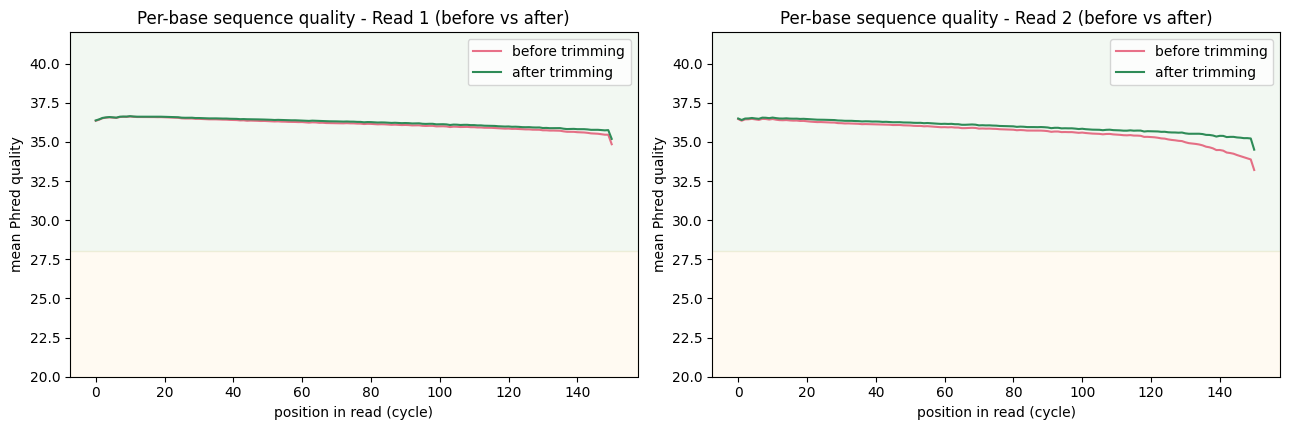

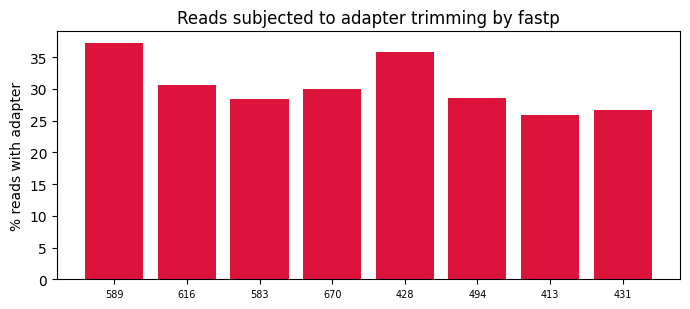

In [11]:
# --- Task 1b: FastQC before/after trimming + per-base quality / adapter comparison ---
raw_fqc  = QC/'raw_fastqc'; raw_fqc.mkdir(parents=True, exist_ok=True)
trim_fqc = QC/'trimmed_fastqc'; trim_fqc.mkdir(parents=True, exist_ok=True)
# (a0) FastQC on the RAW reads before trimming (idempotent) - reproduces the raw-read QC step
need_raw = [sid for sid in samples.index if not (raw_fqc/f'{sid}_1_fastqc.zip').exists()]
if need_raw:
    rf = ' '.join(f'/project/data/raw_fastq/{samples.loc[sid,"fastq_1"]} /project/data/raw_fastq/{samples.loc[sid,"fastq_2"]}' for sid in need_raw)
    docker_run(['bash','-lc', f'fastqc -t {THREADS} -o /project/results/qc/raw_fastqc {rf}'], log_name='nb_fastqc_raw.log')
# (a) FastQC on any trimmed read still lacking a report (idempotent; runs in the Docker image)
need = [sid for sid in samples.index if not (trim_fqc/f'{sid}_1.trimmed_fastqc.zip').exists()]
if need:
    files = ' '.join(f'/project/data/fastq_trimmed/{sid}_{r}.trimmed.fastq.gz' for sid in need for r in (1,2))
    docker_run(['bash','-lc', f'fastqc -t {THREADS} -o /project/results/qc/trimmed_fastqc {files}'],
               log_name='nb_fastqc_trimmed.log')
# (b) aggregate raw FastQC + trimmed FastQC + fastp into one before/after MultiQC report
mqc_ba = QC/'multiqc'/'multiqc_fastqc_beforeafter.html'
if not mqc_ba.exists():
    docker_run(['multiqc','/project/results/qc/raw_fastqc','/project/results/qc/trimmed_fastqc',
                '/project/results/qc/fastp','-o','/project/results/qc/multiqc',
                '-n','multiqc_fastqc_beforeafter','-f'], log_name='nb_multiqc_ba.log')
print('Before/after MultiQC report ->', mqc_ba)

# (c) Per-base sequence quality BEFORE vs AFTER, from the fastp JSONs (all 8 samples)
import numpy as _np
def _curve(section):
    arr=[]
    for sid in samples.index:
        d=json.loads((QC/'fastp'/f'{sid}.fastp.json').read_text())
        m=d.get(section,{}).get('quality_curves',{}).get('mean')
        if m: arr.append(m)
    L=min(len(a) for a in arr); return _np.array([a[:L] for a in arr]).mean(0)
fig, ax = plt.subplots(1, 2, figsize=(13,4.4))
for j,(r,lab) in enumerate([('read1','Read 1'),('read2','Read 2')]):
    b=_curve(f'{r}_before_filtering'); a=_curve(f'{r}_after_filtering')
    ax[j].plot(b, color='crimson', alpha=.6, label='before trimming'); ax[j].plot(a, color='seagreen', label='after trimming')
    ax[j].axhspan(28,42, color='green', alpha=.05); ax[j].axhspan(20,28, color='orange', alpha=.05)
    ax[j].set_ylim(20,42); ax[j].set_xlabel('position in read (cycle)'); ax[j].set_ylabel('mean Phred quality')
    ax[j].set_title(f'Per-base sequence quality - {lab} (before vs after)'); ax[j].legend()
plt.tight_layout(); plt.savefig(QC/'perbase_quality_before_after.png', dpi=150); plt.show()
before_ad=[]
for sid in samples.index:
    d=json.loads((QC/'fastp'/f'{sid}.fastp.json').read_text()); tot=d['summary']['before_filtering']['total_reads']
    before_ad.append(100*d['adapter_cutting']['adapter_trimmed_reads']/tot)
fig, ax = plt.subplots(figsize=(7,3.2)); x=range(len(samples))
ax.bar(x, before_ad, color='crimson')
ax.set_xticks(list(x)); ax.set_xticklabels([s[-3:] for s in samples.index], fontsize=7)
ax.set_ylabel('% reads with adapter'); ax.set_title('Reads subjected to adapter trimming by fastp')
plt.tight_layout(); plt.savefig(QC/'adapter_trimmed_fraction.png', dpi=150); plt.show()

In [12]:
# --- FastQC module status (raw vs trimmed): parse summary.txt from each FastQC report ---
import zipfile
def fastqc_status(folder, suffix):
    rows = {}
    for sid in samples.index:
        z = folder / f'{sid}{suffix}_fastqc.zip'
        if not z.exists(): continue
        with zipfile.ZipFile(z) as zf:
            name = [n for n in zf.namelist() if n.endswith('summary.txt')][0]
            for line in zf.read(name).decode().splitlines():
                status, module, _ = line.split('\t')
                rows.setdefault(module, {})[sid[-3:]] = status
    return pd.DataFrame(rows).T
key_modules = ['Per base sequence quality', 'Per sequence quality scores', 'Adapter Content',
               'Overrepresented sequences', 'Sequence Duplication Levels']
raw_status  = fastqc_status(raw_fqc,  '_1')
trim_status = fastqc_status(trim_fqc, '_1.trimmed')
print('FastQC module status on RAW reads (R1, per sample):')
display(raw_status.reindex([m for m in key_modules if m in raw_status.index]))
print('FastQC module status on TRIMMED reads (R1, per sample):')
display(trim_status.reindex([m for m in key_modules if m in trim_status.index]))
if 'Adapter Content' in raw_status.index:
    _ac = dict(raw_status.loc['Adapter Content'].value_counts())
    print(f'Adapter Content module (raw reads), status counts across samples: {_ac}')

FastQC module status on RAW reads (R1, per sample):


,589,616,583,670,428,494,413,431
Per base sequence quality,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Per sequence quality scores,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Adapter Content,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL
Overrepresented sequences,WARN,WARN,WARN,WARN,WARN,WARN,WARN,WARN
Sequence Duplication Levels,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL


FastQC module status on TRIMMED reads (R1, per sample):


,589,616,583,670,428,494,413,431
Per base sequence quality,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Per sequence quality scores,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Adapter Content,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
Overrepresented sequences,WARN,WARN,WARN,WARN,WARN,WARN,WARN,WARN
Sequence Duplication Levels,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL,FAIL


Adapter Content module (raw reads), status counts across samples: {'FAIL': np.int64(8)}


### Deliverable 1 - QC paragraph

> The 8 CD4+ T-cell libraries (GSE137143) are **paired-end Illumina, 2 x 151 bp**, with high base
> quality (**>92% of bases >=Q30**). The main QC feature is **adapter read-through**: fastp
> auto-detects the **Illumina TruSeq adapter** and trims it from **~26-37% of reads per sample**;
> the fragment insert-size peak (~134-165 bp) means many fragments are near or below the read
> length, so the sequencer reads into the adapter (the definitive evidence is the adapter-trimmed
> fraction, `adapter_evidence.csv`). FastQC independently flags *Adapter Content* as FAIL on the
> raw reads. GC content is broadly consistent across samples and does not flag an additional sample-level
> outlier. FastQC *Sequence Duplication Levels* remains FAIL after trimming: adapter trimming and read
> deduplication are different operations, and the preprocessing did not intentionally remove duplicate
> reads. fastp reported its own duplication estimate, but FastQC and fastp compute duplication with
> different algorithms, so the two percentages are not directly interchangeable. High duplication in
> RNA-seq can arise from genuine repeated sampling of highly expressed transcripts as well as from
> technical PCR duplication, and these sources cannot be reliably separated from raw FASTQ sequence
> identity alone without UMIs. Duplication is broadly consistent across the eight samples, so it does
> not identify a single sample-specific outlier and is reported as a QC limitation rather than a reason
> to discard samples or to deduplicate the RNA-seq library. Light
> fastp trimming raised the Salmon mapping rate by ~+3-6 pp on the samples with an archived raw
> run; the overall rate stays relatively **low (37-46%)**. This is partly expected for a
> transcriptome-only index on rRNA-depleted whole-transcriptome libraries, where genome-derived
> fragments are not represented in the reference. The **quantified counts are clean** (~84% protein-coding, ~1% mitochondrial/rRNA), so the
> matrix is not rRNA-contaminated; the relatively low mapping is consistent with a transcriptome-only index on rRNA-depleted
> whole-transcriptome libraries. Unassigned fragments may include intronic, intergenic, incompletely
> annotated, or other genome-derived reads, whose exact composition was not directly determined here. It is reported as a
> **quantification-quality limitation that constrains the DEA/enrichment to the transcriptomic
> fraction** (a decoy-aware index or a genome alignment could improve mapping of genome-like reads, but not
> all unmapped reads would necessarily become valid transcript counts; building a decoy index needs
> >16 GB RAM and is out of scope here). No sample was excluded based solely on read-level QC - but sample-level QC on the counts (Task 2b)
> flagged one sample with a **myeloid/monocyte-like profile**, which was replaced before DEA.

## Part 1 - Task 2: Quantification with Salmon (gene-level)

We use a **transcriptome-only Salmon index** (GENCODE v28, no decoy) rather than a
decoy-aware one, which would add the whole GRCh38 genome as a decoy sequence but needs
**>16 GB RAM**, too heavy for this laptop. A decoy-aware index can improve handling of
genome-like reads, but unmapped reads cannot be assumed to become valid transcript counts.
A decoy-aware index (which would add the GRCh38 genome as a decoy sequence and need substantially more
memory) is therefore not used in this analysis.

Quantification passes the transcript-to-gene map so Salmon writes
**gene-level** counts directly (`quant.genes.sf`) via `--geneMap`, instead of quantifying
transcripts and aggregating them to gene level in a separate step. Salmon's `NumReads` are estimated
fragment counts (not raw genomic read counts) and are rounded to integers for PyDESeq2. The index build and the per-sample quantification are run inline in the notebook on the
**fastp-trimmed** reads, one sample at a time (~60-70 min/sample).

In [13]:
# --- Reference (GENCODE v28, GRCh38) - download if missing, else reuse ---
# GENCODE v28 was chosen to match the annotation used to build tx2gene.tsv / gene_annotation.tsv.
# Source (documented for the report):
#   https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_28/
GENCODE28 = 'https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_28'
tx_fa  = REF / 'gencode.v28.transcripts.fa.gz'          # transcriptome -> Salmon index
gtf_gz = REF / 'gencode.v28.annotation.gtf.gz'          # annotation -> tx2gene / gene symbols
genome = REF / 'GRCh38.p12.genome.fa.gz'                 # only needed for an optional decoy-aware index (not used here)

import urllib.request
def fetch(url, dest):
    if dest.exists():
        print(dest.name, '- already present, skip download'); return
    print('downloading', dest.name, '...')
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, dest)
    print('  done:', dest)

fetch(f'{GENCODE28}/gencode.v28.transcripts.fa.gz', tx_fa)
fetch(f'{GENCODE28}/gencode.v28.annotation.gtf.gz', gtf_gz)
# The GRCh38 genome FASTA would only be required for an optional decoy-aware index and is not needed
# for the transcriptome-only index used in this analysis (~3 GB; left undownloaded).
# fetch(f'{GENCODE28}/GRCh38.p12.genome.fa.gz', genome)

for f in [tx_fa, gtf_gz]:
    assert f.exists(), f'Missing reference file: {f}'
print('\nReference OK:', tx_fa.name, '+', gtf_gz.name)
print('Genome (decoy, optional):', genome.name, '- present:', genome.exists())

# Record MD5 checksums of the reference files (single authority and release: GENCODE 28, kept
# consistent from FASTA through GTF through the gene-symbol map).
import hashlib
def _md5(p, buf=1<<20):
    h=hashlib.md5()
    with open(p,'rb') as _fh:
        for _c in iter(lambda: _fh.read(buf), b''): h.update(_c)
    return h.hexdigest()
for _f in [tx_fa, gtf_gz, REF/'tx2gene.tsv']:
    if _f.exists(): print(f'  md5  {_f.name:34} {_md5(_f)}')
print('All reference files are GENCODE release 28 (single authority + release) - FASTA/GTF/tx2gene consistent.')

gencode.v28.transcripts.fa.gz - already present, skip download
gencode.v28.annotation.gtf.gz - already present, skip download

Reference OK: gencode.v28.transcripts.fa.gz + gencode.v28.annotation.gtf.gz
Genome (decoy, optional): GRCh38.p12.genome.fa.gz - present: True


  md5  gencode.v28.transcripts.fa.gz      3417c67b959bea58fedd2afe59096ff5


  md5  gencode.v28.annotation.gtf.gz      0c64fd0ab90aef446119d113ca62252f


  md5  tx2gene.tsv                        5a8571cb1f5f59d5f79459ba009d273e
All reference files are GENCODE release 28 (single authority + release) - FASTA/GTF/tx2gene consistent.


In [14]:
# --- tx2gene map (verify) + Salmon index build (idempotent, transcriptome-only) ---
t2g_path = REF / 'tx2gene.tsv'   # 2-col (transcript_id, gene_id), also passed to salmon --geneMap
assert t2g_path.exists(), f'Missing {t2g_path}'
t2g = pd.read_csv(t2g_path, sep='\t', header=None, names=['tx','gene_id'])
print('tx2gene:', t2g.shape, '- sample:')
print(t2g.head(3).to_string(index=False))

# Build the transcriptome-only Salmon index if it's not already there (~7-8 min, ~1.5 GB RAM).
# NOTE: no `-d decoys.txt` here on purpose (decoy-aware needs >16 GB RAM - see the markdown above).
if (IDX / 'info.json').exists():
    info = json.loads((IDX/'info.json').read_text())
    print(f"\nSalmon index already built: {IDX.name}  (k={info['k']}, num_decoys={info['num_decoys']}, "
          f"num_kmers={info['num_kmers']:,}) - skipping build")
else:
    print('\nBuilding Salmon index (transcriptome-only)...')
    docker_run([
        'salmon', 'index',
        '-t', f'/project/data/reference/{tx_fa.name}',
        '-i', f'/project/data/{IDX.name}',
        '-k', 31, '-p', THREADS,
    ], log_name='nb_salmon_index.log')
    mark_state('index', IDX.name)
    print('Salmon index built ->', IDX)

tx2gene: (203835, 2) - sample:
               tx           gene_id
ENST00000456328.2 ENSG00000223972.5
ENST00000450305.2 ENSG00000223972.5
ENST00000488147.1 ENSG00000227232.5

Salmon index already built: salmon_index_v112_utf8  (k=31, num_decoys=0, num_kmers=127,543,631) - skipping build


In [15]:
# --- Task 2: salmon quant per sample (gene-level via --geneMap), from TRIMMED reads ---
# Idempotent: a sample whose quant.genes.sf exists is skipped. If not yet done this runs
# salmon live (~60-70 min/sample), one sample at a time (RAM-safe). Once quantification has been
# run, all 8 are present and every iteration prints "skip".
QUANT.mkdir(parents=True, exist_ok=True)
for sid, row in samples.iterrows():
    if (QUANT / sid / 'quant.genes.sf').exists():
        print(sid, '- quant already done, skipping')
        continue
    r1 = TRIMMED / f'{sid}_1.trimmed.fastq.gz'
    r2 = TRIMMED / f'{sid}_2.trimmed.fastq.gz'
    if not (r1.exists() and r2.exists()):
        print(sid, '- trimmed reads missing, run Task 1 (fastp) first. Skipping.')
        continue
    print(sid, '- running salmon quant (slow, ~60-70 min)...')
    docker_run([
        'salmon', 'quant',
        '-i', f'/project/data/{IDX.name}',
        '-l', 'A', '-p', THREADS,
        '-1', f'/project/data/fastq_trimmed/{sid}_1.trimmed.fastq.gz',
        '-2', f'/project/data/fastq_trimmed/{sid}_2.trimmed.fastq.gz',
        '--geneMap', '/project/data/reference/tx2gene.tsv',   # -> gene-level quant.genes.sf
        '--validateMappings', '--gcBias', '--seqBias',        # selective alignment + bias correction
        '-o', f'/project/data/salmon_quants/{sid}',
    ], log_name=f'nb_quant_{sid}.log')
    mark_state('quant', sid)
    print(sid, '- quant done')

# Aggregate salmon logs (mapping rates etc.) into MultiQC (idempotent: skip if already built)
multiqc_salmon = QC / 'multiqc' / 'multiqc_salmon.html'
if multiqc_salmon.exists():
    print('MultiQC (salmon) already built, skipping ->', multiqc_salmon)
else:
    docker_run(['multiqc', '/project/data/salmon_quants',
                '-o', '/project/results/qc/multiqc', '-n', 'multiqc_salmon', '-f'],
               log_name='nb_multiqc_salmon.log')

missing_quant = [sid for sid in samples.index if not (QUANT/sid/'quant.genes.sf').exists()]
print('\nSamples still missing quant:', missing_quant if missing_quant else 'none - all 8 done')

SRR10089589 - quant already done, skipping
SRR10089616 - quant already done, skipping
SRR10089583 - quant already done, skipping
SRR10089670 - quant already done, skipping
SRR10089428 - quant already done, skipping
SRR10089494 - quant already done, skipping
SRR10089413 - quant already done, skipping
SRR10089431 - quant already done, skipping
MultiQC (salmon) already built, skipping -> E:\MS_CD4\results\qc\multiqc\multiqc_salmon.html

Samples still missing quant: none - all 8 done


In [16]:
# --- Empirical justification for trimming: mapping rate RAW vs TRIMMED ---
# Salmon writes num_processed / num_mapped / percent_mapped into aux_info/meta_info.json.
# We read it for the current (trimmed) quants and, where available, the archived raw-read
# quants, so the effect of trimming is shown with numbers (a strong point for the report).
RAW_ARCHIVE = DATA / 'salmon_quants_rawreads_archive'

def mapping_rate(quant_root, sid):
    mi = quant_root / sid / 'aux_info' / 'meta_info.json'
    if not mi.exists():
        return None
    d = json.loads(mi.read_text())
    return {'percent_mapped': round(d.get('percent_mapped', float('nan')), 2),
            'num_processed_M': round(d.get('num_processed', 0)/1e6, 1),
            'num_mapped_M': round(d.get('num_mapped', 0)/1e6, 1)}

rows = []
for sid in samples.index:
    raw = mapping_rate(RAW_ARCHIVE, sid)
    trim = mapping_rate(QUANT, sid)
    rows.append({
        'sample_id': sid,
        'condition': samples.loc[sid, 'condition'],
        'raw_%mapped':     raw['percent_mapped']  if raw  else np.nan,
        'trimmed_%mapped': trim['percent_mapped'] if trim else np.nan,
        'delta_pp': (round(trim['percent_mapped'] - raw['percent_mapped'], 2)
                     if (raw and trim) else np.nan),
    })
map_cmp = pd.DataFrame(rows).set_index('sample_id')
map_cmp.to_csv(QC / 'mapping_rate_raw_vs_trimmed.csv')
print('Mapping rate: raw (archived) vs trimmed. delta_pp = percentage-point change from trimming.')
print('(raw column is NaN for the 4 final samples without an archived raw run: 3 HC + the replacement MS SRR10089494.)')
# Salmon auto-detected library type (strandedness) per sample, from -l A:
def _libtype(sid):
    mi=QUANT/sid/'aux_info'/'meta_info.json'
    if mi.exists():
        lt=json.loads(mi.read_text()).get('library_types'); return lt[0] if lt else '?'
    return '?'
print('Salmon library type (-l A auto-detect):', {sid:_libtype(sid) for sid in samples.index})
map_cmp

Mapping rate: raw (archived) vs trimmed. delta_pp = percentage-point change from trimming.
(raw column is NaN for the 4 final samples without an archived raw run: 3 HC + the replacement MS SRR10089494.)
Salmon library type (-l A auto-detect): {'SRR10089589': 'ISR', 'SRR10089616': 'ISR', 'SRR10089583': 'ISR', 'SRR10089670': 'ISR', 'SRR10089428': 'ISR', 'SRR10089494': 'ISR', 'SRR10089413': 'ISR', 'SRR10089431': 'ISR'}


,condition,raw_%mapped,trimmed_%mapped,delta_pp
sample_id,,,,
SRR10089589,HC,NaN,36.92,NaN
SRR10089616,HC,NaN,39.17,NaN
SRR10089583,HC,NaN,39.89,NaN
SRR10089670,HC,41.15,45.74,4.59
SRR10089428,MS,39.21,45.43,6.22
SRR10089494,MS,NaN,39.89,NaN
SRR10089413,MS,35.74,38.90,3.16
SRR10089431,MS,41.00,45.04,4.04


In [17]:
# --- Build the gene-level count matrix (Deliverable 2) ---
# quant.genes.sf columns: Name, Length, EffectiveLength, TPM, NumReads
counts_csv = DEA / 'gene_counts_matrix.csv'
if counts_csv.exists() and list(pd.read_csv(counts_csv, index_col=0, nrows=0).columns)==list(samples.index):
    counts = pd.read_csv(counts_csv, index_col=0)
    print('Loaded existing gene count matrix:', counts.shape)
else:
    assert not missing_quant, f'Cannot build count matrix, missing quant for: {missing_quant}'
    mats = {}
    for sid in samples.index:
        sf = QUANT / sid / 'quant.genes.sf'
        df = pd.read_csv(sf, sep='\t').set_index('Name')
        mats[sid] = df['NumReads']
    counts = pd.DataFrame(mats)
    counts.index = counts.index.str.replace(r'\.\d+$', '', regex=True)   # strip Ensembl version
    counts = counts.groupby(level=0).sum()
    counts = counts.round().astype(int)
    counts = counts.loc[:, samples.index]   # keep column order = sample sheet
    counts.to_csv(counts_csv)
    print('Gene count matrix:', counts.shape)
counts

Loaded existing gene count matrix: (57964, 8)


,SRR10089589,SRR10089616,SRR10089583,SRR10089670,SRR10089428,SRR10089494,SRR10089413,SRR10089431
Name,,,,,,,,
ENSG00000000003,49,37,57,76,33,66,36,119
ENSG00000000005,0,0,0,0,0,0,0,0
ENSG00000000419,498,387,243,504,544,451,417,575
ENSG00000000457,1432,1081,1144,1624,1278,1371,1425,1741
ENSG00000000460,334,278,274,463,334,239,382,417
...,...,...,...,...,...,...,...,...
ENSG00000285498,0,0,0,0,0,0,0,0
ENSG00000285505,34,0,0,0,0,140,0,0
ENSG00000285508,0,0,0,0,0,0,0,0


In [18]:
# --- Quantification QC: gene-biotype composition and mitochondrial/rRNA fraction of the counts ---
# A low Salmon mapping rate can hide a library-quality issue, so we break the counts down by gene
# biotype and quantify the mitochondrial + rRNA share. A large Mt/rRNA fraction would indicate
# incomplete rRNA depletion.
_annq = pd.read_csv(REF/'gene_annotation.tsv', sep='\t'); _annq['gene_id'] = _annq['gene_id'].str.replace(r'\.\d+$','',regex=True)
_sym = _annq.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']
_bio = _annq.drop_duplicates('gene_id').set_index('gene_id')['gene_biotype']
lib = counts.sum(0)
biotype = pd.Series(counts.index.map(_bio), index=counts.index).fillna('unknown')
comp = (counts.groupby(biotype).sum().sum(1) / lib.sum() * 100).sort_values(ascending=False)
print('Count fraction by gene biotype (% of assigned reads, cohort total):')
print(comp.head(8).round(2).to_string())
sym = pd.Series(counts.index.map(_sym), index=counts.index).astype(str)
mt_mask = sym.str.startswith('MT-').values
rrna_mask = biotype.isin(['rRNA','Mt_rRNA','rRNA_pseudogene']).values
mt_frac   = (counts[mt_mask].sum(0)/lib*100).round(1)
mtrrna_frac = (counts[mt_mask | rrna_mask].sum(0)/lib*100).round(1)
print('\nMitochondrial-gene count fraction per sample (%):', mt_frac.to_dict())
print('Mitochondrial + rRNA count fraction per sample (%):', mtrrna_frac.to_dict())
print(f'protein_coding share (cohort): {comp.get("protein_coding",0):.0f}%  |  mean mitochondrial+rRNA per sample: {mtrrna_frac.mean():.1f}%')

Count fraction by gene biotype (% of assigned reads, cohort total):
Name
protein_coding          84.19
misc_RNA                 5.85
lincRNA                  2.99
processed_transcript     1.30
snRNA                    1.19
ribozyme                 1.07
antisense                0.62
miRNA                    0.57

Mitochondrial-gene count fraction per sample (%): {'SRR10089589': 1.7, 'SRR10089616': 1.2, 'SRR10089583': 1.6, 'SRR10089670': 0.9, 'SRR10089428': 1.2, 'SRR10089494': 1.0, 'SRR10089413': 1.2, 'SRR10089431': 0.9}
Mitochondrial + rRNA count fraction per sample (%): {'SRR10089589': 1.7, 'SRR10089616': 1.2, 'SRR10089583': 1.6, 'SRR10089670': 0.9, 'SRR10089428': 1.2, 'SRR10089494': 1.0, 'SRR10089413': 1.2, 'SRR10089431': 0.9}
protein_coding share (cohort): 84%  |  mean mitochondrial+rRNA per sample: 1.2%


### Quantification QC - interpretation

The counts are dominated by protein-coding genes with only a small mitochondrial/rRNA fraction, so
the matrix is not rRNA-dominated. The ~40% overall Salmon mapping is consistent with a transcriptome-only index on rRNA-depleted
whole-transcriptome libraries. Unassigned fragments may include intronic, intergenic, incompletely
annotated, or other genome-derived reads; their exact composition was not directly determined in this
mini-study. This restricts the analysis to the transcriptomic fraction (see Task 2 and the Limitations).

## Part 1 - Task 2b: Sample-level QC - outlier detection and replacement

Before differential expression, sample-level QC on the quantified counts is mandatory. The
reference study (Kim et al., 2021) explicitly ran PCA and sample-distance clustering and
removed mis-sorted / outlier samples before DEA. Screening the **initially selected 8 samples**
by PCA, sample correlation and cell-identity markers flagged one sample, **SRR10089503**, as a
clear outlier: a CD4+ library with a strong **myeloid/monocyte-like expression profile** (high `LYZ`,
`CD14`, `S100A9`, `FCN1`, `CST3` with depressed pan-T markers) that dominates PC1 (~83% of the
variance). SRR10089503 showed a discordant expression profile across PCA, sample correlation and
lineage markers and was therefore replaced before differential-expression analysis.

It was therefore **excluded and replaced** by another eligible treatment-naive CD4+ female of
the same age (32 y), **SRR10089494**, restoring the balanced 4 MS / 4 HC, 2F/2M design.
`data/metadata/samples.csv` reflects this **final** selection; the screening data for the
initial 8 (including SRR10089503) is kept under `results/qc/outlier/` to document the decision.

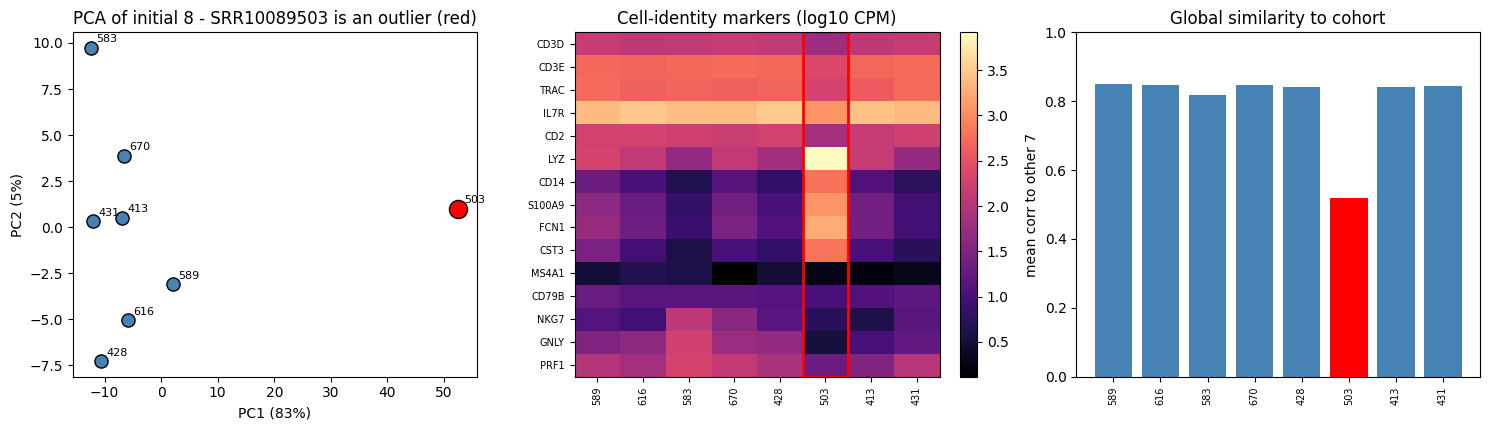

PC1 explains 83% of variance; SRR10089503 PC1 = 52.5 (all others between -12.4 and 2.0).
SRR10089503 mean correlation to others = 0.52 vs 0.84 for the rest.

Myeloid markers (CPM) - SRR10089503 vs cohort median:
  LYZ     SRR10089503=  8292.7   others median= 131.5
  CD14    SRR10089503=   623.6   others median=   9.1
  S100A9  SRR10089503=  1196.0   others median=  18.6
  FCN1    SRR10089503=  1797.5   others median=  22.4
  CST3    SRR10089503=   645.3   others median=   8.0


In [19]:
# --- Screen the INITIALLY selected 8 samples (incl. SRR10089503) for outliers ---
from sklearn.decomposition import PCA
OUTDIR = QC / 'outlier'; OUTDIR.mkdir(parents=True, exist_ok=True)
scr = pd.read_csv(OUTDIR / 'counts_screening_8.csv', index_col=0)   # initial 8, includes SRR10089503
scr_s = pd.read_csv(OUTDIR / 'samples_screening_8.csv', index_col=0)
order = list(scr_s.index)

ann0 = pd.read_csv(REF / 'gene_annotation.tsv', sep='\t')
ann0['gene_id'] = ann0['gene_id'].str.replace(r'\.\d+$', '', regex=True)
id2sym0 = ann0.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']
sym2id0 = {}
for g, s in id2sym0.items(): sym2id0.setdefault(s, g)

lib = scr.sum(0); cpm = scr / lib * 1e6
def cpm_of(sym):
    g = sym2id0.get(sym); return cpm.loc[g] if (g in cpm.index) else None

panels = {'CD4 / pan-T': ['CD3D','CD3E','TRAC','IL7R','CD2'],
          'Myeloid / monocyte': ['LYZ','CD14','S100A9','FCN1','CST3'],
          'B / NK-cytotoxic': ['MS4A1','CD79B','NKG7','GNLY','PRF1']}
rows = []
for grp, ms in panels.items():
    for m in ms:
        v = cpm_of(m)
        if v is not None: rows.append({'panel': grp, 'gene': m, **{s: round(v[s], 1) for s in order}})
markers = pd.DataFrame(rows); markers.to_csv(OUTDIR / 'identity_markers_cpm.csv', index=False)

# global correlation of each sample to the other 7 (top-2000 variable genes)
lg = np.log1p(cpm); tv = lg.var(1).sort_values(ascending=False).head(2000).index
corr = np.corrcoef(lg.loc[tv].T.values)
mean_corr = {order[i]: (corr[i].sum() - 1) / (len(order) - 1) for i in range(len(order))}

# PCA on the screened 8
Xm = np.log1p(cpm).T; tv2 = Xm.var(0).sort_values(ascending=False).head(500).index
Z = Xm[tv2].values; Z = (Z - Z.mean(0)) / (Z.std(0) + 1e-8)
pca = PCA(3).fit(Z); co = pca.transform(Z); var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
for i, s in enumerate(order):
    out = s == 'SRR10089503'
    ax[0].scatter(co[i,0], co[i,1], s=170 if out else 90, c='red' if out else 'steelblue', edgecolor='k', zorder=3)
    ax[0].annotate(s[-3:], (co[i,0], co[i,1]), fontsize=8, xytext=(4,4), textcoords='offset points')
ax[0].set_xlabel(f'PC1 ({var[0]:.0f}%)'); ax[0].set_ylabel(f'PC2 ({var[1]:.0f}%)')
ax[0].set_title('PCA of initial 8 - SRR10089503 is an outlier (red)')
data = np.log10(markers.set_index('gene')[order].values + 1)
im = ax[1].imshow(data, aspect='auto', cmap='magma')
ax[1].set_xticks(range(len(order))); ax[1].set_xticklabels([s[-3:] for s in order], fontsize=7, rotation=90)
ax[1].set_yticks(range(len(markers))); ax[1].set_yticklabels(markers['gene'], fontsize=7)
ax[1].set_title('Cell-identity markers (log10 CPM)'); plt.colorbar(im, ax=ax[1], fraction=0.046)
c503 = order.index('SRR10089503')
ax[1].add_patch(plt.Rectangle((c503-0.5, -0.5), 1, len(markers), fill=False, edgecolor='red', lw=2))
mc = [mean_corr[s] for s in order]
ax[2].bar(range(len(order)), mc, color=['red' if s=='SRR10089503' else 'steelblue' for s in order])
ax[2].set_xticks(range(len(order))); ax[2].set_xticklabels([s[-3:] for s in order], fontsize=7, rotation=90)
ax[2].set_ylim(0,1); ax[2].set_ylabel('mean corr to other 7'); ax[2].set_title('Global similarity to cohort')
plt.tight_layout(); plt.savefig(OUTDIR / 'outlier_SRR10089503.png', dpi=150); plt.show()

print(f'PC1 explains {var[0]:.0f}% of variance; SRR10089503 PC1 = {co[c503,0]:.1f} '
      f'(all others between {min(x for j,x in enumerate(co[:,0]) if j!=c503):.1f} and '
      f'{max(x for j,x in enumerate(co[:,0]) if j!=c503):.1f}).')
print(f'SRR10089503 mean correlation to others = {mean_corr["SRR10089503"]:.2f} '
      f'vs {np.mean([mean_corr[s] for s in order if s!="SRR10089503"]):.2f} for the rest.')
print('\nMyeloid markers (CPM) - SRR10089503 vs cohort median:')
for m in ['LYZ','CD14','S100A9','FCN1','CST3']:
    v = cpm_of(m); med = np.median([v[s] for s in order if s!='SRR10089503'])
    print(f'  {m:7} SRR10089503={v["SRR10089503"]:8.1f}   others median={med:6.1f}')

In [20]:
# --- Sensitivity: DEA with vs without the myeloid-like outlier (on the initial 8) ---
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
def _deg(keep):
    c = scr[keep].T
    k = (c.sum(0) >= 10) & ((c > 0).sum(0) >= 3); c = c.loc[:, k]
    md = scr_s.loc[keep, ['condition', 'sex']].astype(str)
    dds_ = DeseqDataSet(counts=c, metadata=md, design='~sex + condition', quiet=True); dds_.deseq2()
    st_ = DeseqStats(dds_, contrast=['condition', 'MS', 'HC'], quiet=True); st_.summary()
    r = st_.results_df
    return int((r.padj < 0.05).sum())
with_503 = _deg(order)
without_503 = _deg([s for s in order if s != 'SRR10089503'])
print(f'DEGs at padj<0.05  ->  with SRR10089503: {with_503}   |   without it: {without_503}')

DEGs at padj<0.05  ->  with SRR10089503: 22   |   without it: 43


> **Decision.** SRR10089503 shows a strong myeloid/monocyte-like expression profile incompatible with the other CD4 libraries: it dominates the PCA
> (~83% of PC1), correlates poorly with the cohort (r ~ 0.5 vs ~0.85), shows myeloid markers
> approximately 60-80-fold the cohort median. It is therefore **excluded on independent QC grounds (cell-identity incompatibility)** and replaced by **SRR10089494** (treatment-naive CD4+, female, 32 y). All
> downstream analyses use the final, replaced cohort recorded in `samples.csv`; exclusion was based exclusively on independent cell-identity QC, and the change in DEG yield is reported only as a sensitivity result. The identity check below indicates that no final sample shows the extreme myeloid-like profile of SRR10089503 (all retain strong T-cell markers).

In [21]:
# --- Final-cohort identity check: converging marker evidence (no single hard cutoff) ---
lib_f = counts.sum(0); cpm_f = counts / lib_f * 1e6
def _cpm(sym):
    g = sym2id0.get(sym); return cpm_f.loc[g] if (g in cpm_f.index) else pd.Series(np.nan, index=counts.columns)
chk = pd.DataFrame({
    'CD3E (T)':  _cpm('CD3E').round(0),
    'TRAC (T)':  _cpm('TRAC').round(0),
    'CD4 (T)':   _cpm('CD4').round(0),
    'LYZ (myeloid)':   _cpm('LYZ').round(0),
    'CD14 (myeloid)':  _cpm('CD14').round(0),
    'MS4A1 (B)':    _cpm('MS4A1').round(1),
}, index=counts.columns)
print('Final cohort identity markers (CPM):'); print(chk.to_string())

Final cohort identity markers (CPM):
             CD3E (T)  TRAC (T)  CD4 (T)  LYZ (myeloid)  CD14 (myeloid)  MS4A1 (B)
SRR10089589     529.0     540.0    498.0          198.0            21.0        2.2
SRR10089616     482.0     447.0    409.0          132.0             9.0        3.7
SRR10089583     510.0     481.0    470.0           46.0             4.0        3.1
SRR10089670     560.0     440.0    447.0          134.0            12.0        0.3
SRR10089428     515.0     477.0    397.0           66.0             5.0        2.1
SRR10089494     510.0     492.0    417.0           83.0             9.0        1.8
SRR10089413     512.0     394.0    401.0          141.0            11.0        0.7
SRR10089431     560.0     544.0    455.0           49.0             5.0        1.1


## Part 1 - Task 3: Differential Expression Analysis (PyDESeq2)

We use **PyDESeq2** (Python port of DESeq2). The design `~ sex + condition` includes **sex as a
covariate** and **condition as the biological effect of interest**, so the **MS-vs-HC** effect
(HC = reference) is estimated after accounting for sex-associated expression variability. No
sex-by-condition interaction term is added, and age is not included as a covariate because the samples
were deliberately tightly age-matched and show almost no age variation. Low-count genes are pre-filtered
before testing.

In [22]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# PyDESeq2 wants samples x genes
counts_t = counts.T
keep = (counts_t.sum(axis=0) >= 10) & ((counts_t > 0).sum(axis=0) >= 3)   # >=10 reads total, present in >=3 samples
counts_t = counts_t.loc[:, keep]
meta = samples[['condition','sex','age']].copy()
meta['condition'] = meta['condition'].astype(str)
meta['sex'] = meta['sex'].astype(str)
print('Genes after filtering:', counts_t.shape[1])

dds = DeseqDataSet(counts=counts_t, metadata=meta, design='~ sex + condition', refit_cooks=True)
dds.deseq2()

Genes after filtering: 26094


Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...


... done in 8.83 seconds.

Fitting dispersion trend curve...


... done in 1.40 seconds.

Fitting MAP dispersions...


... done in 9.77 seconds.

Fitting LFCs...


... done in 6.04 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [23]:
dea_full_csv = DEA / 'dea_results_full.csv'
sample_tag = ','.join(sorted(samples.index))
tagf = DEA/'.dea_samples.txt'
cache_ok = dea_full_csv.exists() and tagf.exists() and tagf.read_text().strip()==sample_tag
if cache_ok:
    res = pd.read_csv(dea_full_csv, index_col=0)
    print('Loaded cached DEA (same sample set):', res.shape)
else:
    stat = DeseqStats(dds, contrast=['condition','MS','HC'])   # MS vs HC
    stat.summary()
    res = stat.results_df.copy(); res.index.name = 'gene_id'
    res = res.sort_values('padj'); res.to_csv(dea_full_csv); tagf.write_text(sample_tag)

ann = pd.read_csv(REF/'gene_annotation.tsv', sep='\t'); ann['gene_id'] = ann['gene_id'].str.replace(r'\.\d+$','',regex=True)
id2name = ann.drop_duplicates('gene_id').set_index('gene_id')['gene_symbol']
id2bt   = ann.drop_duplicates('gene_id').set_index('gene_id')['gene_biotype']
res['symbol']  = pd.Series(res.index.map(id2name), index=res.index).fillna(pd.Series(res.index, index=res.index))
res['biotype'] = pd.Series(res.index.map(id2bt), index=res.index)

PADJ, LFC = 0.05, 1.0
# Report BOTH criteria (the paper used FDR 5% without a fold-change cut-off; we add |log2FC|>=1 too)
n_fdr  = int((res['padj'] < PADJ).sum())
sig    = res[(res['padj'] < PADJ) & (res['log2FoldChange'].abs() >= LFC)].copy()
up, down = sig[sig['log2FoldChange']>0], sig[sig['log2FoldChange']<0]
res[res['padj']<PADJ].to_csv(DEA/'DEGs_FDR05.csv')                 # FDR-only DEGs (paper-equivalent)
sig.to_csv(DEA/'DEGs_FDR05_LFC1.csv')                              # FDR + fold-change (strong-effect subset)
up.to_csv(DEA/'DEGs_upregulated.csv'); down.to_csv(DEA/'DEGs_downregulated.csv')
print(f'DEGs at padj<{PADJ} (paper-equivalent): {n_fdr}')
print(f'DEGs at padj<{PADJ} & |log2FC|>={LFC}: {len(sig)}  (up={len(up)}, down={len(down)})')

Loaded cached DEA (same sample set): (26094, 6)


DEGs at padj<0.05 (paper-equivalent): 44
DEGs at padj<0.05 & |log2FC|>=1.0: 25  (up=8, down=17)


Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.



Fitting dispersions...


... done in 8.14 seconds.



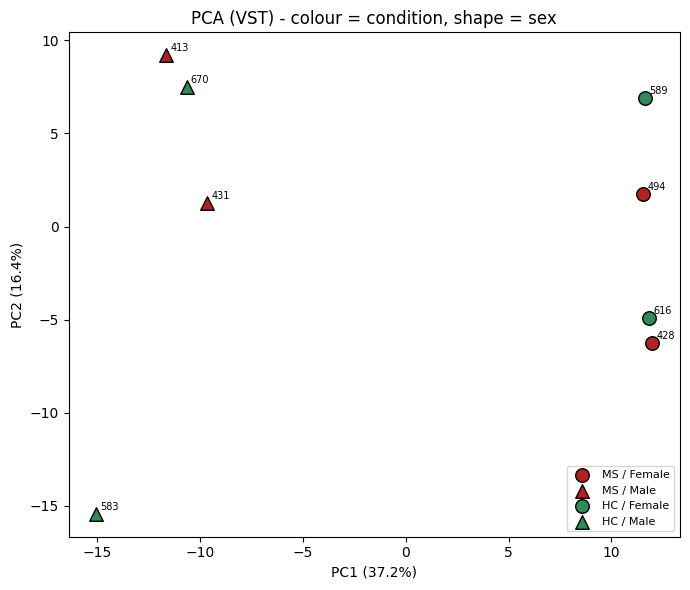

In [24]:
# --- PCA on the 500 most variable genes after VST (DESeq2 plotPCA convention: centered, NOT per-gene scaled) ---
from sklearn.decomposition import PCA
dds.vst(use_design=False)                              # variance-stabilizing transform
vst = pd.DataFrame(dds.layers['vst_counts'], index=counts_t.index, columns=counts_t.columns)
topvar = vst.var(0).sort_values(ascending=False).head(500).index
X = vst[topvar].values; X = X - X.mean(0)          # center only (matches DESeq2 plotPCA; no per-gene scaling)
pcs = PCA(n_components=2).fit(X); co = pcs.transform(X)
pc = pd.DataFrame(co, index=counts_t.index, columns=['PC1','PC2']).join(meta); var = pcs.explained_variance_ratio_*100
# Condition and sex shown simultaneously: colour = condition, marker shape = sex
_mk = {'F':'o','M':'^'}; _co = {'MS':'firebrick','HC':'seagreen'}
fig, ax = plt.subplots(figsize=(7,6))
for cond in ['MS','HC']:
    for sx in ['F','M']:
        s = pc[(pc['condition']==cond) & (pc['sex']==sx)]
        if len(s):
            ax.scatter(s['PC1'], s['PC2'], s=95, c=_co[cond], marker=_mk[sx], edgecolor='k',
                       label=f'{cond} / {"Female" if sx=="F" else "Male"}')
for sid in pc.index:
    ax.annotate(sid[-3:], (pc.loc[sid,'PC1'], pc.loc[sid,'PC2']), fontsize=7, xytext=(3,3), textcoords='offset points')
ax.set_xlabel(f'PC1 ({var[0]:.1f}%)'); ax.set_ylabel(f'PC2 ({var[1]:.1f}%)')
ax.set_title('PCA (VST) - colour = condition, shape = sex'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(DEA/'PCA.png', dpi=150); plt.show()

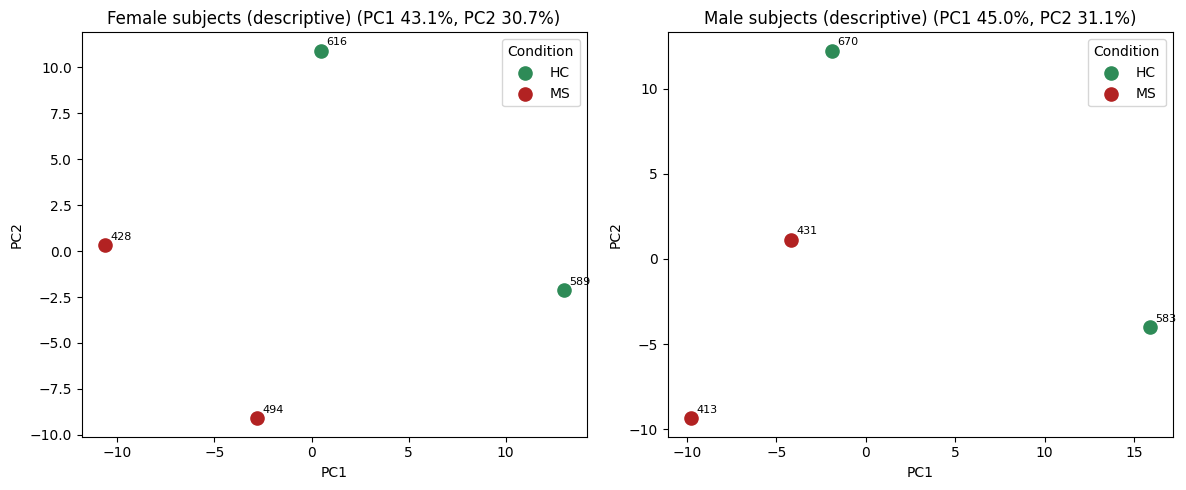

In [25]:
# --- PCA computed separately within each sex (top-variable VST genes per subgroup), coloured by condition ---
# vst is oriented samples x genes, so subgroup samples are selected by row with .loc (not by column).
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, sx, title in zip(axes, ['F', 'M'], ['Female subjects (descriptive)', 'Male subjects (descriptive)']):
    sids = samples.index[samples['sex'] == sx].tolist()
    Xsub = vst.loc[sids]                                  # subgroup samples x genes
    topvar_sex = Xsub.var(axis=0).sort_values(ascending=False).head(min(200, Xsub.shape[1])).index
    Z = Xsub[topvar_sex].values
    Z = Z - Z.mean(axis=0)                                # center only (DESeq2 plotPCA convention)
    pca = PCA(n_components=2, random_state=SEED)
    co = pca.fit_transform(Z)
    var = pca.explained_variance_ratio_ * 100
    plot_df = pd.DataFrame(co, index=sids, columns=['PC1', 'PC2']).join(samples[['condition']])
    for cond, color in [('HC', 'seagreen'), ('MS', 'firebrick')]:
        d = plot_df[plot_df['condition'] == cond]
        ax.scatter(d['PC1'], d['PC2'], s=90, color=color, label=cond)
    for sid in plot_df.index:
        ax.annotate(sid[-3:], (plot_df.loc[sid, 'PC1'], plot_df.loc[sid, 'PC2']),
                    fontsize=8, xytext=(4, 4), textcoords='offset points')
    ax.set_title(f'{title} (PC1 {var[0]:.1f}%, PC2 {var[1]:.1f}%)')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='Condition')
plt.tight_layout()
plt.savefig(DEA / 'PCA_separate_by_sex.png', dpi=150)
plt.show()

### PCA - interpretation

MS and HC do not separate strongly on PC1/PC2, while part of the visible structure is associated
with sex; this supports including sex as a covariate in the overall design (`~ sex + condition`).
Age is not included because the cohort is tightly age-matched at selection. The within-sex PCA
(2 MS vs 2 HC per panel) is descriptive only and complements the overall PCA.

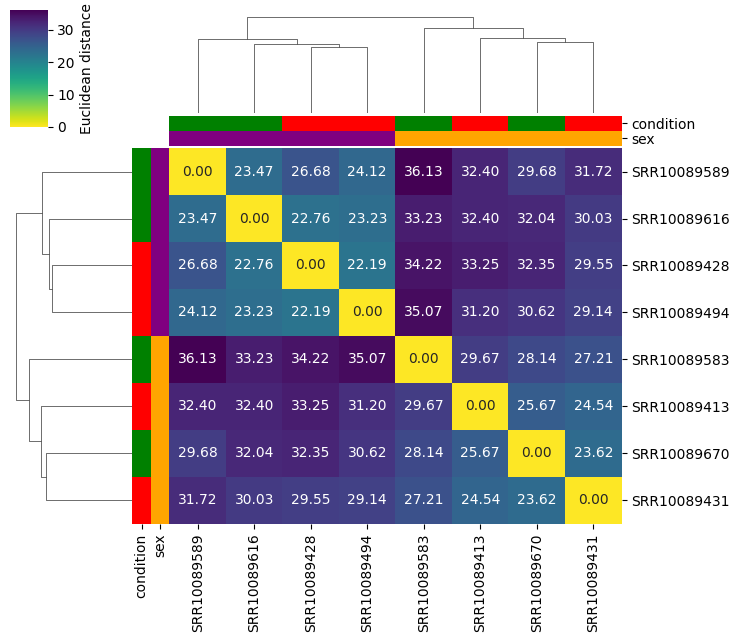

In [26]:
# --- Sample-distance heatmap: cluster with an EXPLICIT linkage built from the condensed distances ---
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage
condensed = pdist(vst[topvar].values, metric='euclidean')      # 1-D condensed distances (VST space)
dd = pd.DataFrame(squareform(condensed), index=counts_t.index, columns=counts_t.index)
row_link = linkage(condensed, method='average')                # linkage from the SAME distances
row_cols = pd.DataFrame({
    'condition': meta['condition'].map({'MS':'red','HC':'green'}),
    'sex': meta['sex'].map({'F':'purple','M':'orange'}),
}, index=counts_t.index)
# show numeric distances in the heatmap (not just the clustering) and use the SAME linkage for rows and columns
g = sns.clustermap(dd, row_linkage=row_link, col_linkage=row_link, cmap='viridis_r', figsize=(7.5,6.5),
                   row_colors=row_cols, col_colors=row_cols, annot=True, fmt='.2f', cbar_kws={'label':'Euclidean distance'})
g.savefig(DEA/'sample_distance_heatmap.png', dpi=150); plt.show()

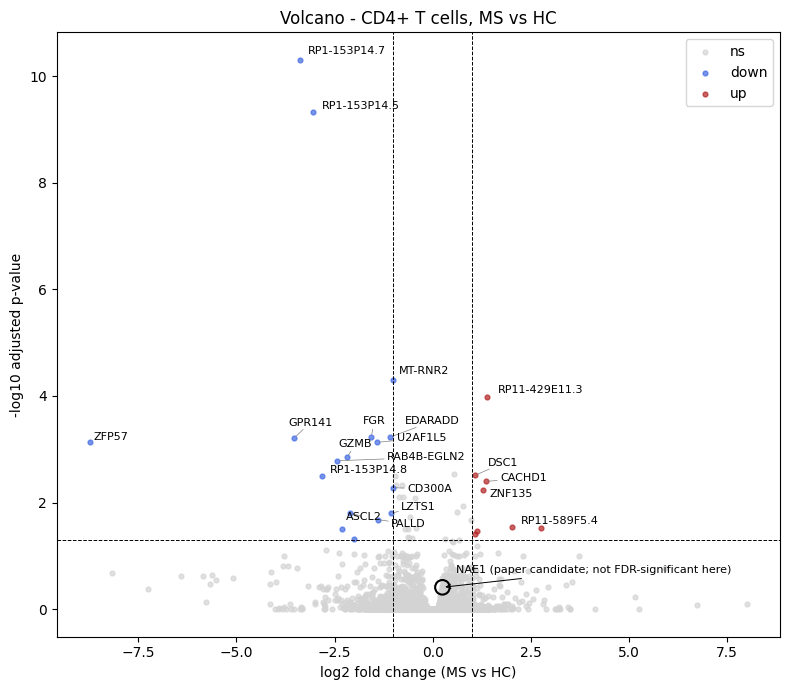

In [27]:
# --- Volcano plot, labelled with GENE SYMBOLS ---
try:
    from adjustText import adjust_text
    HAVE_ADJUST = True
except Exception:
    HAVE_ADJUST = False

v = res.dropna(subset=['padj']).copy()
v['neglog10p'] = -np.log10(v['padj'].clip(lower=1e-300))
v['cat'] = 'ns'
v.loc[(v['padj']<PADJ)&(v['log2FoldChange']>=LFC), 'cat'] = 'up'
v.loc[(v['padj']<PADJ)&(v['log2FoldChange']<=-LFC), 'cat'] = 'down'
colors = {'ns':'lightgrey','up':'firebrick','down':'royalblue'}

fig, ax = plt.subplots(figsize=(8,7))
for c in ['ns','down','up']:
    s = v[v['cat']==c]
    ax.scatter(s['log2FoldChange'], s['neglog10p'], s=12, c=colors[c], label=c, alpha=0.7)
ax.axhline(-np.log10(PADJ), ls='--', c='k', lw=0.7)
ax.axvline(LFC, ls='--', c='k', lw=0.7); ax.axvline(-LFC, ls='--', c='k', lw=0.7)
ax.set_xlabel('log2 fold change (MS vs HC)'); ax.set_ylabel('-log10 adjusted p-value')
ax.set_title('Volcano - CD4+ T cells, MS vs HC'); ax.legend()
# label top genes by symbol
lab = v[v['cat']!='ns'].sort_values('padj').head(20)
texts = [ax.text(r['log2FoldChange'], r['neglog10p'], r['symbol'], fontsize=8) for _, r in lab.iterrows()]
if HAVE_ADJUST:
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
# Highlight NAE1 (paper candidate) whatever its category, without recolouring it as significant
_nae1 = v[v['symbol']=='NAE1']
if len(_nae1):
    r0 = _nae1.iloc[0]
    ax.scatter(r0['log2FoldChange'], r0['neglog10p'], s=110, facecolors='none', edgecolors='black', linewidths=1.5, zorder=6)
    ax.annotate('NAE1 (paper candidate; not FDR-significant here)', (r0['log2FoldChange'], r0['neglog10p']),
                fontsize=8, xytext=(10,10), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.7))
plt.tight_layout(); plt.savefig(DEA/'volcano.png', dpi=150); plt.show()

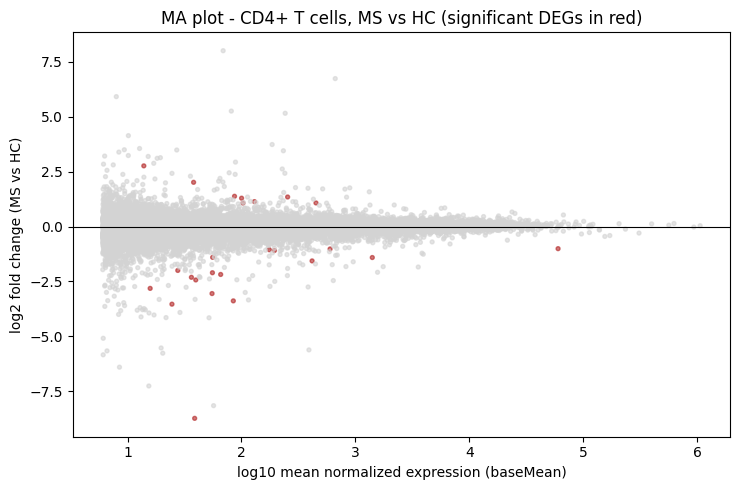

In [28]:
# --- MA plot: log2 mean expression vs log2 fold change (normalization diagnostic) ---
ma = res.dropna(subset=['padj']).copy()
ma['sig'] = (ma['padj'] < PADJ) & (ma['log2FoldChange'].abs() >= LFC)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(np.log10(ma['baseMean'] + 1), ma['log2FoldChange'], s=8,
           c=np.where(ma['sig'], 'firebrick', 'lightgrey'), alpha=0.6)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('log10 mean normalized expression (baseMean)')
ax.set_ylabel('log2 fold change (MS vs HC)')
ax.set_title('MA plot - CD4+ T cells, MS vs HC (significant DEGs in red)')
plt.tight_layout(); plt.savefig(DEA/'MA_plot.png', dpi=150); plt.show()

### MA plot - interpretation

The fold-change distribution is centred around zero, with no evident global shift. The largest
fold-changes occur at low expression, where they are least reliable.

In [29]:
# --- Top-20 DEG table (smallest padj); reader-facing columns with gene symbol first ---
top20 = res.sort_values('padj').head(20).reset_index()
top20 = top20.rename(columns={top20.columns[0]: 'ensembl_id'})
top20 = top20[['symbol','ensembl_id','log2FoldChange','pvalue','padj','baseMean','biotype']].copy()
top20['FDR_and_LFC_significant'] = (top20['padj'] < PADJ) & (top20['log2FoldChange'].abs() >= LFC)
top20 = top20.round({'log2FoldChange':2,'baseMean':1})
top20.to_csv(DEA/'top20_DEGs.csv', index=False)
top20

,symbol,ensembl_id,log2FoldChange,pvalue,padj,baseMean,biotype,FDR_and_LFC_significant
0,RP1-153P14.7,ENSG00000279942,-3.39,2.305072e-15,4.965355e-11,83.9,TEC,True
1,RP1-153P14.5,ENSG00000227920,-3.05,4.427569e-14,4.768714e-10,54.2,lincRNA,True
2,MT-RNR2,ENSG00000210082,-1.01,7.114755e-09,5.108631e-05,60131.7,Mt_rRNA,True
3,RP11-429E11.3,ENSG00000179253,1.38,1.949463e-08,1.049835e-04,85.9,antisense,True
4,FGR,ENSG00000000938,-1.56,1.650576e-07,5.925842e-04,416.0,protein_coding,True
5,EDARADD,ENSG00000186197,-1.09,1.650348e-07,5.925842e-04,193.7,protein_coding,True
6,GPR141,ENSG00000187037,-3.53,2.020321e-07,6.217106e-04,23.5,protein_coding,True
7,U2AF1L5,ENSG00000275895,-1.41,2.772754e-07,7.412911e-04,1406.5,protein_coding,True
8,ZFP57,ENSG00000204644,-8.73,3.097173e-07,7.412911e-04,37.9,protein_coding,True
9,GZMB,ENSG00000100453,-2.18,6.587775e-07,1.419073e-03,64.7,protein_coding,True


In [30]:
# --- Top-20 PROTEIN-CODING DEG table (easier to interpret / feeds the PPI) ---
res_pc = res[res['biotype']=='protein_coding'].sort_values('padj')
top20_pc = res_pc.head(20)[['symbol','log2FoldChange','pvalue','padj','baseMean']].copy()
top20_pc['significant'] = (top20_pc['padj']<PADJ)
top20_pc = top20_pc.round({'log2FoldChange':2,'baseMean':1})
top20_pc.to_csv(DEA/'top20_DEGs_protein_coding.csv')
top20_pc

,symbol,log2FoldChange,pvalue,padj,baseMean,significant
gene_id,,,,,,
ENSG00000186197,EDARADD,-1.09,1.650348e-07,0.000593,193.7,True
ENSG00000000938,FGR,-1.56,1.650576e-07,0.000593,416.0,True
ENSG00000187037,GPR141,-3.53,2.020321e-07,0.000622,23.5,True
ENSG00000275895,U2AF1L5,-1.41,2.772754e-07,0.000741,1406.5,True
ENSG00000204644,ZFP57,-8.73,3.097173e-07,0.000741,37.9,True
ENSG00000100453,GZMB,-2.18,6.587775e-07,0.001419,64.7,True
ENSG00000171570,RAB4B-EGLN2,-2.43,8.377906e-07,0.001641,38.7,True
ENSG00000116191,RALGPS2,0.54,1.597085e-06,0.002867,587.7,True
ENSG00000134765,DSC1,1.08,1.860320e-06,0.003083,450.1,True


## Part 1 - Task 4: Enrichment analysis

Because the 4-vs-4 design is under-powered, we use **two complementary approaches**:

**Primary - ranked GSEA (`gseapy.prerank`).** Every gene tested by DESeq2 is ranked by its
**Wald statistic** (`stat`, the signed test statistic that combines effect size and
confidence), and GSEA asks whether each gene set is concentrated at the top (up in MS) or
bottom (down in MS) of that ranking. GSEA uses the **whole ranked list**, so it does not
depend on an arbitrary DEG cut-off and keeps power when few genes pass FDR - the appropriate
primary readout here.

**Secondary - over-representation analysis (ORA, `gseapy.enrichr`).** Run on the **DEGs passing padj<0.05 and |log2FC|>=1** (Task 3), separately for up- and down-regulated genes, with an explicit
**background = all genes tested by DESeq2** (not the whole genome). With so few FDR DEGs this is only a sanity check that complements GSEA.

> The relaxed nominal-p protein-coding set defined in Part 2 is **not** used here - it is only
> the relaxed-network input for the STRING analysis.

In [31]:
import gseapy as gp

GENE_SETS = ['GO_Biological_Process_2023', 'Reactome_2022', 'KEGG_2021_Human']

# ---------- PRIMARY: ranked GSEA on ALL tested genes (DESeq2 Wald statistic) ----------
gsea_csv = ENRICH / 'gsea_prerank.csv'
# rank = signed Wald stat; collapse duplicate symbols by mean, drop NaN
rnk = (res.loc[counts_t.columns, ['symbol', 'stat']].dropna()
          .groupby('symbol')['stat'].mean().sort_values(ascending=False))
print('Ranked genes for GSEA:', len(rnk))

if gsea_csv.exists():
    gsea = pd.read_csv(gsea_csv)
    print('Loaded cached GSEA results.')
else:
    pre = gp.prerank(rnk=rnk, gene_sets=GENE_SETS, min_size=10, max_size=500,
                     permutation_num=1000, seed=SEED, threads=THREADS, outdir=None, verbose=False)
    gsea = pre.res2d.copy()
    # normalise column names across gseapy versions
    gsea.columns = [c.strip() for c in gsea.columns]
    fdr_col = 'FDR q-val' if 'FDR q-val' in gsea.columns else [c for c in gsea.columns if 'FDR' in c][0]
    gsea = gsea.rename(columns={fdr_col: 'FDR'})
    gsea['NES'] = pd.to_numeric(gsea['NES'], errors='coerce')
    gsea['FDR'] = pd.to_numeric(gsea['FDR'], errors='coerce')
    gsea = gsea.sort_values('NES', ascending=False)
    gsea.to_csv(gsea_csv, index=False)

sig_gsea = gsea[gsea['FDR'] < 0.05]        # main GSEA significance threshold
print(f'GSEA gene sets at FDR<0.05 (main): {len(sig_gsea)}  |  at FDR<0.25 (permissive conventional): {int((gsea["FDR"]<0.25).sum())}  (of {len(gsea)} tested)')
print('\nTop pathways UP in MS (NES>0):')
print(gsea.sort_values('NES', ascending=False)[['Term','NES','FDR']].head(8).to_string(index=False))
print('\nTop pathways DOWN in MS (NES<0):')
print(gsea.sort_values('NES')[['Term','NES','FDR']].head(8).to_string(index=False))

Ranked genes for GSEA: 25973
Loaded cached GSEA results.
GSEA gene sets at FDR<0.05 (main): 232  |  at FDR<0.25 (permissive conventional): 1058  (of 4850 tested)

Top pathways UP in MS (NES>0):
                                                                                         Term      NES  FDR
                          Reactome_2022__Formation Of A Pool Of Free 40S Subunits R-HSA-72689 2.660222  0.0
Reactome_2022__L13a-mediated Translational Silencing Of Ceruloplasmin Expression R-HSA-156827 2.651592  0.0
               Reactome_2022__GTP Hydrolysis And Joining Of 60S Ribosomal Subunit R-HSA-72706 2.626766  0.0
                              Reactome_2022__Cap-dependent Translation Initiation R-HSA-72737 2.567950  0.0
                                           Reactome_2022__Viral mRNA Translation R-HSA-192823 2.567167  0.0
                                Reactome_2022__Eukaryotic Translation Termination R-HSA-72764 2.566186  0.0
                                Reactome_2022__Euk

In [32]:
# ---------- SECONDARY: ORA on the significant DEGs (up/down separately) ----------
# Background = all genes tested by DESeq2 that have a valid gene symbol (the experimental universe
# that could have entered the foreground), not the Enrichr genome default. Foreground = the
# significant up-/down-regulated DEGs with a valid symbol; foreground is a subset of the background.
background = sorted(set(res.loc[counts_t.columns, 'symbol'].dropna().astype(str)))
print('ORA background size (tested genes with a valid symbol):', len(background))

def ora(symbols, tag):
    out_csv = ENRICH / f'ora_{tag}.csv'
    if out_csv.exists():
        print(f'ora_{tag}: loaded cached results'); return pd.read_csv(out_csv)
    symbols = [s for s in symbols if isinstance(s, str)]
    if len(symbols) < 5:
        print(f'ora_{tag}: only {len(symbols)} genes (<5) -> skipped (limited power at 4-vs-4)'); return None
    r = gp.enrichr(gene_list=symbols, gene_sets=GENE_SETS, organism='human',
                   background=background, outdir=None).results.sort_values('Adjusted P-value')
    r.to_csv(out_csv, index=False)
    return r

# No arbitrary post-DE filter is applied to the foreground. We instead inspect whether mitochondrial
# or ribosomal genes dominate the DEG list (they are kept, not removed by a threshold).
up_fg   = [s for s in up['symbol'].dropna().astype(str).tolist()]
down_fg = [s for s in down['symbol'].dropna().astype(str).tolist()]
_techn = [s for s in up_fg + down_fg if s.startswith('MT-') or s.startswith('RPS') or s.startswith('RPL') or s.startswith('MRPS') or s.startswith('MRPL')]
print(f'Foreground: up={len(up_fg)}, down={len(down_fg)} (subset of the background).')
print('Mitochondrial/ribosomal genes among the DEGs:', _techn if _techn else 'none - the list is not dominated by them')
ora_up   = ora(up_fg,   'up')
ora_down = ora(down_fg, 'down')
print('')
print('ORA down-regulated, top terms:')
if ora_down is not None:
    print(ora_down[['Term','Adjusted P-value']].head(8).to_string(index=False))
print('ORA up-regulated, top terms:')
if ora_up is not None:
    print(ora_up[['Term','Adjusted P-value']].head(8).to_string(index=False))

ORA background size (tested genes with a valid symbol):

 25973
Foreground: up=8, down=17 (subset of the background).
Mitochondrial/ribosomal genes among the DEGs: ['MT-RNR2']
ora_up: loaded cached results
ora_down: loaded cached results

ORA down-regulated, top terms:
                                                                   Term  Adjusted P-value
                  TNFs Bind Their Physiological Receptors R-HSA-5669034          0.003357
                     Regulation Of Mast Cell Degranulation (GO:0043304)          0.004930
                        TNFR2 Non-Canonical NF-kB Pathway R-HSA-5668541          0.024827
                    Negative Regulation Of Immune Response (GO:0050777)          0.047110
Negative Regulation Of Myeloid Leukocyte Mediated Immunity (GO:0002887)          0.048217
                Negative Regulation Of Leukocyte Migration (GO:0002686)          0.048217
            DNA Methylation Involved In Embryo Development (GO:0043045)          0.048217
  Negative Regulation Of B Cell Receptor Signaling Pathway (GO:0050

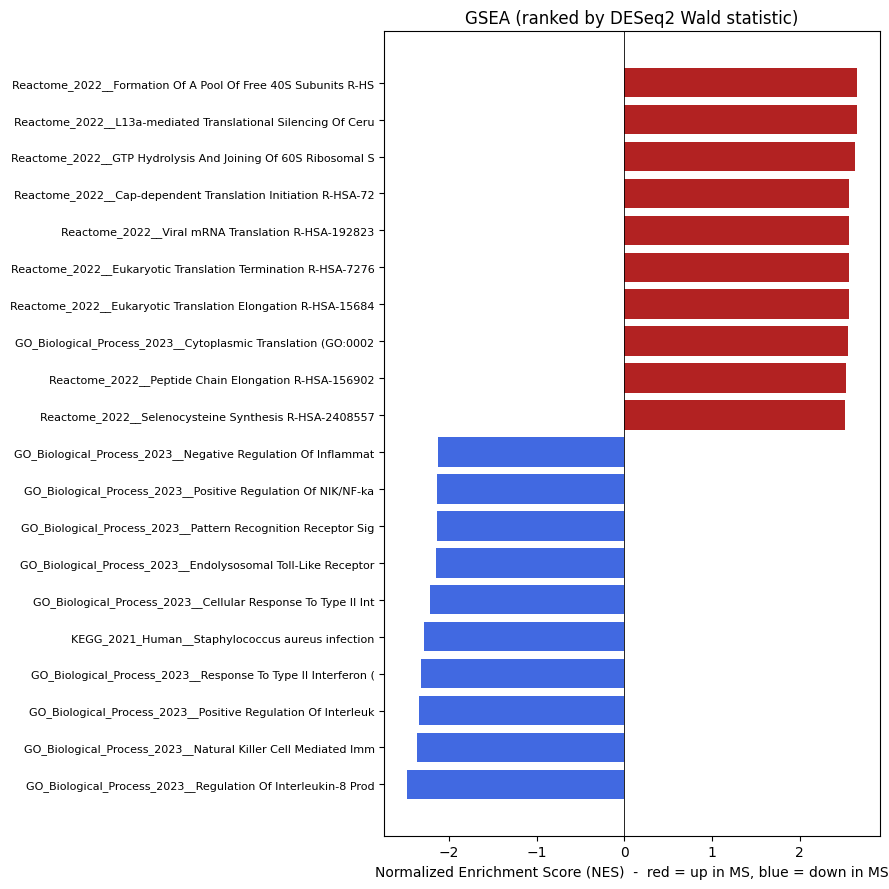

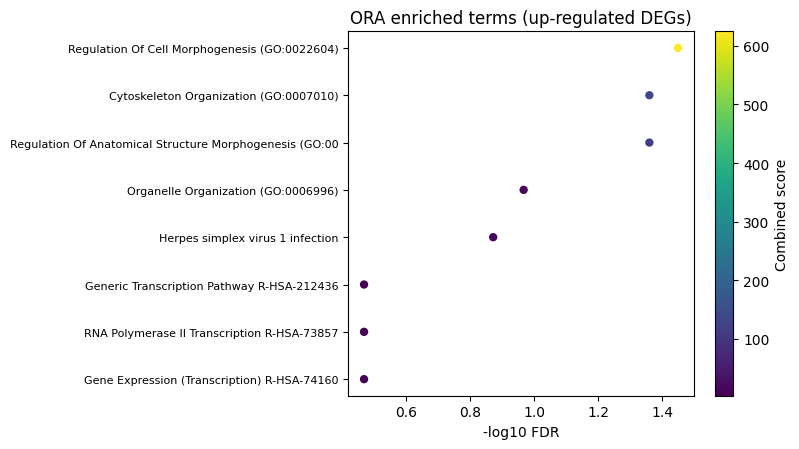

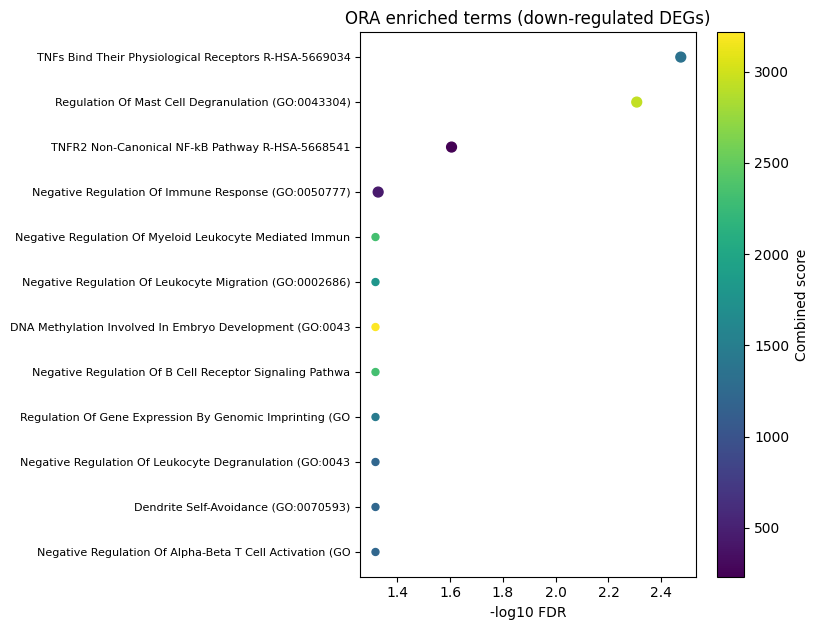

In [33]:
# --- GSEA barplot (top pathways up/down by NES) + ORA dotplot ---
# GSEA: show the strongest positive (up in MS) and negative (down in MS) normalized enrichment scores
def gsea_barplot(g, n=10):
    if g is None or g.empty:
        print('no GSEA results'); return
    top = pd.concat([g.sort_values('NES', ascending=False).head(n),
                     g.sort_values('NES').head(n)]).drop_duplicates('Term')
    top = top.sort_values('NES')
    colors = ['firebrick' if x > 0 else 'royalblue' for x in top['NES']]
    fig, ax = plt.subplots(figsize=(9, 0.4*len(top)+1))
    ax.barh(range(len(top)), top['NES'], color=colors)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top['Term'].str.slice(0,60), fontsize=8)
    ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel('Normalized Enrichment Score (NES)  -  red = up in MS, blue = down in MS')
    ax.set_title('GSEA (ranked by DESeq2 Wald statistic)')
    plt.tight_layout(); plt.savefig(ENRICH/'gsea_barplot.png', dpi=150); plt.show()

gsea_barplot(gsea)

# ORA dotplot for the up- and down-regulated DEG subsets (a subset with fewer than 5 genes is skipped)
def dotplot(r, tag, n=12):
    if r is None or r.empty:
        print(f'{tag}: no ORA to plot'); return
    d = r.head(n).copy()
    d['-log10FDR'] = -np.log10(d['Adjusted P-value'].clip(lower=1e-300))
    if 'Overlap' in d.columns:
        d['overlap_n'] = d['Overlap'].str.split('/').str[0].astype(int)
    else:   # this gseapy build returns 'Genes' (semicolon list) instead of 'Overlap'
        d['overlap_n'] = d['Genes'].fillna('').str.split(';').apply(lambda g: len([x for x in g if x]))
    d = d.iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.45*len(d)+1))
    sc = ax.scatter(d['-log10FDR'], range(len(d)), s=d['overlap_n']*25,
                    c=d['Combined Score'], cmap='viridis')
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Term'].str.slice(0,55), fontsize=8)
    ax.set_xlabel('-log10 FDR'); ax.set_title(f'ORA enriched terms ({tag})')
    plt.colorbar(sc, label='Combined score'); plt.tight_layout()
    plt.savefig(ENRICH/f'ora_dotplot_{tag}.png', dpi=150); plt.show()

dotplot(ora_up,   'up-regulated DEGs')
dotplot(ora_down, 'down-regulated DEGs')

### Deliverable 4 - biological interpretation of the enrichment

**Primary readout (GSEA, final cohort).** Translation and ribosome-related gene sets are positively
enriched in MS (formation of the 40S/60S subunits, cap-dependent initiation, elongation/termination;
NES ~2.5-2.7, FDR<0.001). Several immune and interferon-associated gene sets show negative enrichment -
interferon-gamma response, IL-8 production, NK-cell-mediated immunity and TLR/NF-kB signalling
(NES ~ -2.1 to -2.5). A weaker protein-ubiquitination signal is also present (E3 ubiquitin ligases,
protein ubiquitination; NES ~1.9, FDR ~0.01-0.02).

> **Note.** Given the small sample size and the redundancy among gene sets, interpretation focuses on
> coherent biological themes (translation up; interferon/IL-8/NK-associated immune programs down)
> rather than on isolated pathway terms. Enrichment indicates that genes annotated to those programs
> are coordinately shifted; it does not imply that the sorted CD4 samples are those cell types.

## Part 1 - Task 5: Comparison with the paper

**Paper's key CD4 conclusion.** Kim et al. (*Brain* 2021) report that CD4+ T cells from
treatment-naive MS patients up-regulate the **neddylation pathway** and nominate **NAE1**
(NEDD8-activating enzyme) as a therapeutic target, with additional evidence (UBE2F, VHL,
AKIP1, SMURF1, "Ubl conjugation" enrichment) and experimental validation with pevonedistat.

**What this mini-study recovers (final cohort).**
- **NAE1 is directionally and nominally consistent with the paper** (log2FC +0.25, nominal
  p ~ 0.005) **but does not survive multiple-testing correction** (padj ~ 0.39) at 4-vs-4. The full neddylation core (UBA3, UBE2F, UBE2M, NEDD8, CUL1, RBX1)
  is essentially flat (see the targeted table below).
- **The dominant up-regulated program is translation / ribosome biogenesis** (GSEA, FDR<0.001),
  with a **secondary, weaker protein-ubiquitination signal** (E3 ubiquitin ligases, protein
  ubiquitination; NES ~1.9, FDR ~0.01-0.02) whose proteasomal-catabolism direction is ambiguous.

**Interpretation.** *The mini-study does not confirm NAE1 after FDR correction (though its direction and nominal p are consistent). It
detects a broad translation signature plus a weaker ubiquitin/E3-ligase signal that is
directionally compatible with, but not specific evidence for, increased neddylation.*

**Expected discrepancies.** 4-vs-4 is under-powered (few FDR DEGs, noisy effect sizes), it is a
single cell-type slice, and the paper used the full cohort with validation - so pathway-level hints
rather than exact-gene reproduction are the appropriate claim. The assignment required Salmon
(transcriptome quasi-mapping), whereas the paper used STAR 2-pass genome alignment followed by RSEM;
mapping statistics are therefore not directly comparable, and unmapped reads cannot be assumed to
become valid transcript counts.

In [34]:
# --- Targeted neddylation / ubiquitin table (my direction vs the paper's) ---
ned_genes = ['NAE1','UBA3','UBE2F','UBE2M','NEDD8','CUL1','RBX1','VHL','AKIP1','SMURF1']
paper_dir = {'NAE1':'up','UBE2F':'up','VHL':'up','AKIP1':'up','SMURF1':'up'}  # reported in Kim et al.
rows=[]
for g in ned_genes:
    r = res[res['symbol']==g]
    if len(r):
        rows.append({'gene':g,'baseMean':round(r['baseMean'].values[0],1),
                     'log2FC':round(r['log2FoldChange'].values[0],2),
                     'pvalue':f"{r['pvalue'].values[0]:.2g}",'padj':f"{r['padj'].values[0]:.2g}",
                     'my_direction':'up' if r['log2FoldChange'].values[0]>0 else 'down',
                     'paper_direction':paper_dir.get(g,'-')})
ned_tbl = pd.DataFrame(rows); ned_tbl.to_csv(DEA/'neddylation_genes.csv', index=False)
print('Neddylation/ubiquitin core - none reaches padj<0.05 in this mini-study:')
ned_tbl

Neddylation/ubiquitin core - none reaches padj<0.05 in this mini-study:


,gene,baseMean,log2FC,pvalue,padj,my_direction,paper_direction
0,NAE1,1162.8,0.25,0.0054,0.39,up,up
1,UBA3,1495.0,0.11,0.35,1,up,-
2,UBE2F,1107.4,0.12,0.4,1,up,up
3,UBE2M,775.0,-0.06,0.61,1,down,-
4,NEDD8,980.8,-0.07,0.51,1,down,-
5,CUL1,2674.6,0.05,0.58,1,up,-
6,RBX1,716.2,0.02,0.84,1,up,-
7,VHL,3025.5,0.16,0.17,1,up,up
8,AKIP1,340.2,-0.14,0.43,1,down,up
9,SMURF1,1269.3,-0.20,0.076,0.94,down,up


# Part 2 (Prof. Milazzo) - PPI network, communities, drug repurposing

Starting from the Part-1 differential expression, we (1) build a STRING **physical** PPI network from
the primary DEG set, (2) rank nodes by network-theoretic centralities and define a disease module,
(3) detect communities and relate them to the Part-1 enrichment, and (4) add the DrugBank targets of
three MS drugs (**Betaferon, Tecfidera, Ocrevus**) and compute drug-disease network proximity.

**Primary network.** The primary PPI is built from the primary DEG set (adjusted p-value < 0.05). Only
protein-coding DEGs are eligible for STRING physical mapping; non-protein-coding DEGs are reported as
not eligible. STRING-mapped proteins are kept even when they have no physical edge (degree-zero
isolates). Only physical interactions are used, at combined score >= 400. Degree and betweenness are computed on
the full primary PPI (isolates included), while closeness, eigenvector centrality and Louvain community
detection are evaluated on the largest connected component, where path-based and spectral measures are
meaningful; the disease module is drawn from the connected primary nodes.

**Sensitivity network.** Because the primary FDR network is sparse at this sample size, a relaxed
network (nominal p < 0.05 and |log2FC| >= 0.58, protein-coding) is analysed only as a sensitivity
analysis; it does not replace the primary result. A STRING score >= 700 threshold is also reported as
a sensitivity check.

In [35]:
import requests, networkx as nx
from io import StringIO
STRING_API = 'https://string-db.org/api'
def string_network(genes, species=9606, required_score=400, net_type='physical'):
    params = {'identifiers':'%0d'.join(genes),'species':species,'required_score':required_score,
              'network_type':net_type,'caller_identity':'bsb_assignment'}
    r = requests.post(f'{STRING_API}/tsv/network', data=params, timeout=180); r.raise_for_status()
    return pd.read_csv(StringIO(r.text), sep='\t')
def string_ids(genes, species=9606):
    r = requests.post(f'{STRING_API}/tsv/get_string_ids',
        data={'identifiers':'\r'.join(genes),'species':species,'echo_query':1,'caller_identity':'bsb_assignment'}, timeout=180)
    r.raise_for_status(); m = pd.read_csv(StringIO(r.text), sep='\t')
    col = 'queryItem' if 'queryItem' in m.columns else m.columns[0]
    return dict(zip(m[col].astype(str), m['preferredName']))

# ---- PRIMARY assignment PPI: built from the exact Part-1 DEG set (FDR padj<PADJ) ----
# A PPI is a protein-protein network: only protein-coding DEGs can produce nodes and are queried in
# STRING. Non-protein-coding DEGs are reported as not eligible for PPI mapping (ncRNAs are not turned
# into protein nodes); protein-coding DEGs that STRING does not map are reported as STRING-unmapped.
# All STRING-mapped proteins are kept, including those with no physical edge (degree-zero isolates).
deg_all = res[res['padj'] < PADJ].copy()
deg_pc  = sorted(set(deg_all.loc[deg_all['biotype']=='protein_coding','symbol'].dropna().astype(str)))
deg_nc  = sorted(set(deg_all.loc[deg_all['biotype']!='protein_coding','symbol'].dropna().astype(str)))
edges_primary = string_network(deg_pc, required_score=400, net_type='physical')
edges_primary.to_csv(NET/'string_edges_primary.tsv', sep='\t', index=False)
sym2pref = string_ids(deg_pc)
mapped_pref = sorted(set(sym2pref.values()))
unmapped_pc = sorted(set(deg_pc) - set(sym2pref))
Gp = nx.Graph(); Gp.add_nodes_from(mapped_pref)
for _, e in edges_primary.iterrows():
    Gp.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
interacting = [n for n in Gp if Gp.degree(n) > 0]
isolates    = [n for n in Gp if Gp.degree(n) == 0]
print('PRIMARY DEG PPI funnel (biotype-aware):')
print(f'  total Part-1 DEGs (padj<{PADJ}): {deg_all["symbol"].dropna().nunique()}')
print(f'  protein-coding DEGs (eligible for PPI): {len(deg_pc)} | non-protein-coding (not eligible): {len(deg_nc)}')
print(f'  STRING-mapped proteins: {len(mapped_pref)} | STRING-unmapped protein-coding: {len(unmapped_pc)}')
print(f'  interacting proteins: {len(interacting)} | mapped isolates (degree 0): {len(isolates)} | edges: {Gp.number_of_edges()}')
print(f'  connected components: {nx.number_connected_components(Gp)} '
      f'| largest connected component: {len(max(nx.connected_components(Gp), key=len)) if Gp.number_of_nodes() else 0} nodes')
nx.write_graphml(Gp, NET/'ppi_primary_network.graphml')

# ---- SECONDARY relaxed sensitivity network (SENSITIVITY ONLY; nominal p<0.05 & |log2FC|>=0.58, PC) ----
# Reported separately because the FDR-DEG PPI above is too sparse for informative topology at 4-vs-4;
# it does NOT replace the primary assignment result.
ppi_genes = sorted(set(res.loc[(res['pvalue']<0.05)&(res['log2FoldChange'].abs()>=0.58)
                                &(res['biotype']=='protein_coding'),'symbol'].dropna().astype(str)))
edges_csv = NET / 'string_edges.tsv'
if edges_csv.exists() and edges_csv.stat().st_size > 200:
    edges = pd.read_csv(edges_csv, sep='\t')
else:
    edges = string_network(ppi_genes, required_score=400, net_type='physical'); edges.to_csv(edges_csv, sep='\t', index=False)
pd.Series(ppi_genes, name='gene').to_csv(NET/'ppi_input_genes.csv', index=False)
print(f'\nSECONDARY relaxed sensitivity network: {len(ppi_genes)} genes sent (nominal p<0.05, |log2FC|>=0.58, protein-coding).')
edges_primary.head()

PRIMARY DEG PPI funnel (biotype-aware):
  total Part-1 DEGs (padj<0.05): 44
  protein-coding DEGs (eligible for PPI): 33 | non-protein-coding (not eligible): 11
  STRING-mapped proteins: 31 | STRING-unmapped protein-coding: 2
  interacting proteins: 5 | mapped isolates (degree 0): 26 | edges: 10
  connected components: 27 | largest connected component: 5 nodes



SECONDARY relaxed sensitivity network: 362 genes sent (nominal p<0.05, |log2FC|>=0.58, protein-coding).


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000289316,9606.ENSP00000366679,H2BC5,H2AC12,9606,0.439,0,0,0,0,0.072,0.4,0.074
1,9606.ENSP00000289316,9606.ENSP00000351589,H2BC5,H2AC13,9606,0.618,0,0,0,0,0.072,0.4,0.369
2,9606.ENSP00000289316,9606.ENSP00000358155,H2BC5,H2AC18,9606,0.668,0,0,0,0,0.072,0.4,0.452
3,9606.ENSP00000289316,9606.ENSP00000477527,H2BC5,H2BC17,9606,0.887,0,0,0,0,0.819,0.4,0.000
4,9606.ENSP00000351589,9606.ENSP00000477527,H2AC13,H2BC17,9606,0.613,0,0,0,0,0.361,0.4,0.074


In [36]:
# --- PRIMARY topology: centrality + community detection on the DEG PPI (assignment-compliant) ---
# The full primary graph (isolates included) is retained. Degree and betweenness are reported on the
# full graph; closeness and eigenvector are path-based and are computed on the largest connected
# component (LCC), because they are not comparable across disconnected components. Isolates are kept
# and reported separately; the primary disease module is drawn only from connected primary nodes.
import networkx.algorithms.community as nxcom
deg_p = dict(Gp.degree())
btw_p = nx.betweenness_centrality(Gp, weight=None)
if Gp.number_of_edges():
    lcc_nodes = max(nx.connected_components(Gp), key=len)
    Gp_lcc = Gp.subgraph(lcc_nodes).copy()
    clo_p = nx.closeness_centrality(Gp_lcc)
    try:
        eig_p = nx.eigenvector_centrality(Gp_lcc, max_iter=1000)
    except Exception:
        eig_p = {n: np.nan for n in Gp_lcc}
else:
    Gp_lcc = nx.Graph(); clo_p = {}; eig_p = {}
cent_primary = pd.DataFrame({
    'degree': pd.Series(deg_p), 'betweenness': pd.Series(btw_p),
    'closeness_LCC': pd.Series(clo_p), 'eigenvector_LCC': pd.Series(eig_p)}).fillna(0.0)
cent_primary = cent_primary.sort_values(['degree','betweenness'], ascending=False)
cent_primary.to_csv(NET/'centrality_primary.csv')
connected_primary = [n for n in cent_primary.index if deg_p.get(n, 0) > 0]
disease_module_primary = connected_primary[:15]
print(f'PRIMARY DEG PPI: {Gp.number_of_nodes()} nodes ({len(isolates)} isolates), {Gp.number_of_edges()} edges, '
      f'{nx.number_connected_components(Gp)} components.')
print(f'PRIMARY disease module = connected primary nodes (n={len(disease_module_primary)}): {disease_module_primary}')
if Gp.number_of_edges():
    louvain_p = nxcom.louvain_communities(Gp_lcc, weight='weight', seed=42)
    part_primary = {n: i for i, com in enumerate(louvain_p) for n in com}
    pd.Series(part_primary, name='community').sort_index().to_csv(NET/'communities_primary.csv')
    print(f'PRIMARY Louvain (on LCC): {len(louvain_p)} communities, '
          f'modularity={nxcom.modularity(Gp_lcc, louvain_p, weight="weight"):.3f}')
else:
    print('PRIMARY graph has no edges: community detection not defined.')
cent_primary.head(15)

PRIMARY DEG PPI: 31 nodes (26 isolates), 10 edges, 27 components.
PRIMARY disease module = connected primary nodes (n=5): ['H2AC12', 'H2AC13', 'H2AC18', 'H2BC17', 'H2BC5']
PRIMARY Louvain (on LCC): 1 communities, modularity=-0.000


,degree,betweenness,closeness_LCC,eigenvector_LCC
H2AC12,4,0.0,1.0,0.447214
H2AC13,4,0.0,1.0,0.447214
H2AC18,4,0.0,1.0,0.447214
H2BC17,4,0.0,1.0,0.447214
H2BC5,4,0.0,1.0,0.447214
ADGRE1,0,0.0,0.0,0.000000
APOBEC3G,0,0.0,0.0,0.000000
ASCL2,0,0.0,0.0,0.000000
CACHD1,0,0.0,0.0,0.000000
CD300A,0,0.0,0.0,0.000000


### PPI construction sensitivity - paper-motivated FDR < 0.10

The inspiring paper (Kim et al.) constructed its PPI from significant protein-coding genes at an FDR
cutoff of 0.10. As a PPI-specific sensitivity check, the STRING physical network is rebuilt from the
protein-coding genes at `padj < 0.10` and compared with the primary FDR < 0.05 PPI. The primary DEA
threshold remains FDR < 0.05; these FDR < 0.10 genes are **not** treated as primary DEGs. The FDR < 0.10 network is itself sparse
and fragmented, with a largest connected component still well below a 10-15-node disease module, so it
does not provide a larger connected module; the network-proximity and top-node analyses therefore
continue to use the relaxed sensitivity network.

In [37]:
# --- PPI construction sensitivity: paper-motivated FDR<0.10 protein-coding gene set (NOT primary DEGs) ---
deg010_pc = sorted(set(res.loc[(res['padj'] < 0.10) & (res['biotype'] == 'protein_coding'),
                               'symbol'].dropna().astype(str)))
edges010_csv = NET / 'string_edges_fdr010.tsv'
if edges010_csv.exists() and edges010_csv.stat().st_size > 50:
    edges010 = pd.read_csv(edges010_csv, sep='\t')
else:
    edges010 = string_network(deg010_pc, required_score=400, net_type='physical')
    edges010.to_csv(edges010_csv, sep='\t', index=False)
pref010 = string_ids(deg010_pc)
G010 = nx.Graph(); G010.add_nodes_from(sorted(set(pref010.values())))
for _, e in edges010.iterrows():
    G010.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
_lcc = (lambda g: len(max(nx.connected_components(g), key=len)) if g.number_of_nodes() else 0)
ppi_thr_sens = pd.DataFrame([
    {'threshold': 'FDR<0.05 (primary)', 'eligible_pc_genes': len(deg_pc),
     'string_mapped_nodes': Gp.number_of_nodes(), 'interacting_nodes': len([n for n in Gp if Gp.degree(n) > 0]),
     'edges': Gp.number_of_edges(), 'components': nx.number_connected_components(Gp), 'LCC_nodes': _lcc(Gp)},
    {'threshold': 'FDR<0.10 (paper-motivated sensitivity)', 'eligible_pc_genes': len(deg010_pc),
     'string_mapped_nodes': G010.number_of_nodes(), 'interacting_nodes': len([n for n in G010 if G010.degree(n) > 0]),
     'edges': G010.number_of_edges(), 'components': nx.number_connected_components(G010), 'LCC_nodes': _lcc(G010)},
])
ppi_thr_sens.to_csv(NET / 'ppi_fdr_threshold_sensitivity.csv', index=False)
print('PPI DEG-threshold sensitivity (protein-coding; STRING physical, score>=400):')
print(ppi_thr_sens.to_string(index=False))
print('The primary PPI stays at FDR<0.05; the FDR<0.10 network is a paper-motivated sensitivity view only.')
ppi_thr_sens

PPI DEG-threshold sensitivity (protein-coding; STRING physical, score>=400):
                             threshold  eligible_pc_genes  string_mapped_nodes  interacting_nodes  edges  components  LCC_nodes
                    FDR<0.05 (primary)                 33                   31                  5     10          27          5
FDR<0.10 (paper-motivated sensitivity)                 53                   51                 10     17          44          6
The primary PPI stays at FDR<0.05; the FDR<0.10 network is a paper-motivated sensitivity view only.


,threshold,eligible_pc_genes,string_mapped_nodes,interacting_nodes,edges,components,LCC_nodes
0,FDR<0.05 (primary),33,31,5,10,27,5
1,FDR<0.10 (paper-motivated sensitivity),53,51,10,17,44,6


In [38]:
# --- SENSITIVITY: build the relaxed sensitivity network (largest connected component) ---
# Insert nodes and edges in sorted order so Louvain community detection is deterministic.
G0 = nx.Graph()
for _, e in edges.iterrows():
    G0.add_edge(e['preferredName_A'], e['preferredName_B'], weight=float(e['score']))
G = nx.Graph()
if G0.number_of_nodes():
    lcc = max(nx.connected_components(G0), key=len)
    G.add_nodes_from(sorted(lcc))
    G.add_edges_from(sorted(tuple(sorted((u, v))) for u, v in G0.subgraph(lcc).edges()))
    for u, v in G.edges():
        G[u][v]['weight'] = float(G0[u][v]['weight'])
print('Relaxed sensitivity network (LCC):', G.number_of_nodes(), 'nodes,', G.number_of_edges(), 'edges')
nx.write_graphml(G, NET/'ppi_network.graphml')

Relaxed sensitivity network (LCC): 39 nodes, 55 edges


In [39]:
# --- Sensitivity: relaxed network at STRING score>=400 vs >=700 (same quantities) ---
def relaxed_stats(min_score, edges_df):
    g = nx.Graph()
    for _, r in edges_df.iterrows(): g.add_edge(r['preferredName_A'], r['preferredName_B'])
    comps = list(nx.connected_components(g)) if g.number_of_nodes() else []
    return {'string_score': f'>={min_score}', 'nodes': g.number_of_nodes(), 'edges': g.number_of_edges(),
            'components': len(comps), 'LCC': max((len(c) for c in comps), default=0)}
edges_hi_csv = NET / 'string_edges_hiconf700.tsv'
if edges_hi_csv.exists() and edges_hi_csv.stat().st_size > 200:
    edges_hi = pd.read_csv(edges_hi_csv, sep='\t')
else:
    edges_hi = string_network(ppi_genes, required_score=700, net_type='physical'); edges_hi.to_csv(edges_hi_csv, sep='\t', index=False)
string_sensitivity = pd.DataFrame([relaxed_stats(400, edges), relaxed_stats(700, edges_hi)])
string_sensitivity.to_csv(NET/'string_confidence_sensitivity.csv', index=False)
print('STRING confidence sensitivity on the relaxed sensitivity network (score>=400 vs >=700):')
string_sensitivity

STRING confidence sensitivity on the relaxed sensitivity network (score>=400 vs >=700):


,string_score,nodes,edges,components,LCC
0,>=400,95,198,16,39
1,>=700,60,104,16,20


In [40]:
# --- SENSITIVITY (relaxed network): most relevant nodes via network-theoretic metrics ---
# The relaxed network is analysable where the primary FDR PPI is not; it is reported as a sensitivity
deg_c  = dict(G.degree())
betw   = nx.betweenness_centrality(G, weight=None)
close  = nx.closeness_centrality(G)
try:
    eig = nx.eigenvector_centrality(G, max_iter=1000)
except Exception:
    eig = {n: np.nan for n in G}
cent = pd.DataFrame({'degree':deg_c,'betweenness':betw,'closeness':close,'eigenvector':eig})
# The four standard centralities are reported individually. consensus_centrality_rank is a custom
# summary (the mean percentile rank across the four metrics) used to rank and select the top 15 nodes;
# it is not a standard centrality metric, and the individual metrics are kept in the table below.
cent['consensus_centrality_rank'] = cent.rank(pct=True).mean(axis=1)
cent = cent.sort_values('consensus_centrality_rank', ascending=False)
cent.to_csv(NET/'centrality.csv')
TOPK = 15
disease_module = cent.head(TOPK).index.tolist()   # disease module S (top relevant nodes)
print('Top relevant nodes / disease module (up to', TOPK, '):', disease_module)
cent.head(TOPK)

Top relevant nodes / disease module (up to

 15 ): ['CXCR1', 'PLCG2', 'FCGR3A', 'LYN', 'CXCR2', 'CX3CR1', 'NCAM1', 'KLRK1', 'FASLG', 'XCL1', 'XCL2', 'ITGA2', 'GNAI1', 'CCL3L1', 'CCL4']


,degree,betweenness,closeness,eigenvector,consensus_centrality_rank
CXCR1,7,0.374111,0.308943,0.462730,0.935897
PLCG2,7,0.573969,0.380000,0.057165,0.910256
FCGR3A,5,0.597440,0.365385,0.132785,0.907051
LYN,8,0.589616,0.358491,0.022166,0.884615
CXCR2,7,0.103367,0.253333,0.416985,0.820513
CX3CR1,6,0.050735,0.250000,0.398189,0.762821
NCAM1,3,0.152205,0.281481,0.031059,0.753205
KLRK1,3,0.012091,0.319328,0.044934,0.730769
FASLG,3,0.205548,0.287879,0.005569,0.711538
XCL1,4,0.000474,0.246753,0.344444,0.673077


In [41]:
# --- Relaxed sensitivity PPI: Louvain community detection (modularity-based) ---
import networkx.algorithms.community as nxcom

def label_map(comms):
    m = {}
    for i, c in enumerate(comms):
        for n in c: m[n] = i
    return m

if G.number_of_edges() == 0:
    raise RuntimeError('PPI graph has no edges - relax PPI_P/PPI_LFC in the STRING cell above.')

# Louvain (greedy modularity optimisation, standard for PPI; the community method covered in class)
louvain = nxcom.louvain_communities(G, weight='weight', seed=42)
partition = label_map(louvain)
modularity = nxcom.modularity(G, louvain, weight='weight')
print(f'Relaxed sensitivity PPI - Louvain communities: {len(louvain)}, modularity={modularity:.3f}')

nx.set_node_attributes(G, partition, 'community')
pd.Series(partition, name='community').sort_index().to_csv(NET/'communities.csv')  # sorted -> byte-stable across runs

Relaxed sensitivity PPI - Louvain communities: 6, modularity=0.625


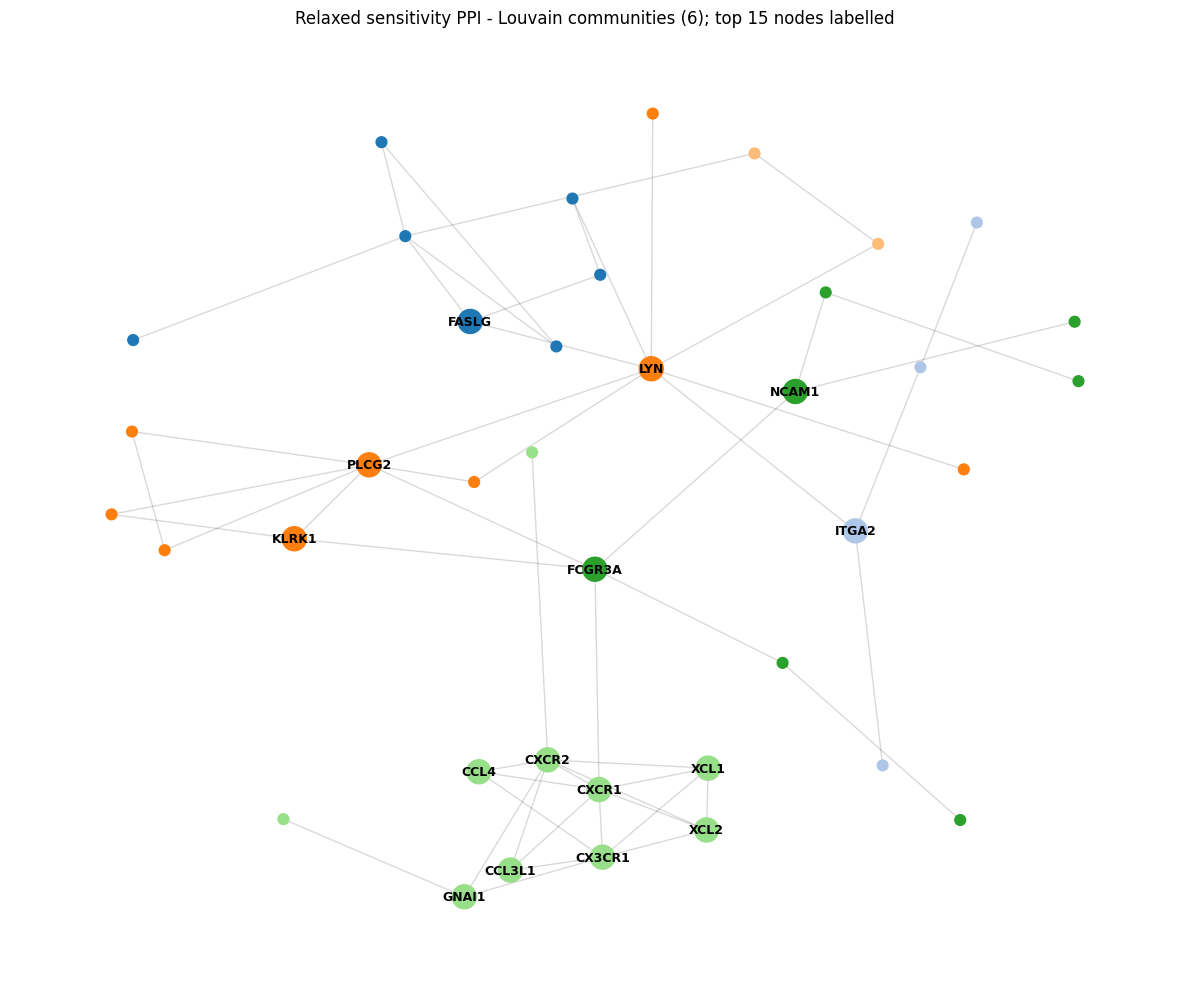

In [42]:
# --- Draw the network coloured by community, top nodes enlarged ---
pos = nx.spring_layout(G, seed=42, k=0.5)
ncomm = len(set(partition.values()))
cmap = plt.cm.tab20
node_col = [cmap(partition[n] % 20) for n in G.nodes()]
node_sz  = [300 if n in disease_module else 60 for n in G.nodes()]
fig, ax = plt.subplots(figsize=(12,10))
nx.draw_networkx_edges(G, pos, alpha=0.15, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_col, node_size=node_sz, ax=ax)
nx.draw_networkx_labels(G, pos, labels={n:n for n in disease_module}, font_size=9, font_weight='bold', ax=ax)
ax.set_title(f'Relaxed sensitivity PPI - Louvain communities ({ncomm}); top {TOPK} nodes labelled'); ax.axis('off')
plt.tight_layout(); plt.savefig(NET/'ppi_communities.png', dpi=150); plt.show()

### Louvain community summary

Compact summary of the Louvain modules of the relaxed sensitivity PPI (one row per community), derived
from the existing `partition`, `cent`, and graph `G`. The complete node-level gene-to-community mapping
remains available in `results/network/communities.csv`.

In [43]:
# --- Compact Louvain community summary (from existing partition / cent / G; no recomputation) ---
_members = {}
for _n, _c in partition.items():
    _members.setdefault(_c, []).append(_n)
_rows = []
for _c in sorted(_members):
    mem = _members[_c]
    n_int = sum(1 for u, v in G.edges() if partition.get(u) == _c and partition.get(v) == _c)
    present = [m for m in mem if m in cent.index]
    ranked = cent.loc[present].sort_values('consensus_centrality_rank', ascending=False).index.tolist()
    ranked = ranked + [m for m in mem if m not in ranked]      # keep any node lacking a centrality row
    _rows.append({'community': _c, 'n_nodes': len(mem), 'n_internal_edges': n_int,
                  'top_central_nodes': ', '.join(ranked[:3]),
                  'representative_genes': ', '.join(ranked[:5])})
community_summary = pd.DataFrame(_rows).sort_values('community').reset_index(drop=True)
community_summary.to_csv(NET / 'community_summary.csv', index=False)
print(f'Louvain communities: {len(community_summary)} (full node-level mapping in communities.csv)')
community_summary

Louvain communities: 6 (full node-level mapping in communities.csv)


,community,n_nodes,n_internal_edges,top_central_nodes,representative_genes
0,0,7,7,"FASLG, TNF, GZMB","FASLG, TNF, GZMB, GNLY, TNFSF11"
1,1,4,3,"ITGA2, LAMB3, ITGAM","ITGA2, LAMB3, ITGAM, CD151"
2,2,9,11,"PLCG2, LYN, KLRK1","PLCG2, LYN, KLRK1, GAB3, KLRC2"
3,3,2,1,"MATK, NTRK1","MATK, NTRK1"
4,4,7,6,"FCGR3A, NCAM1, LILRA4","FCGR3A, NCAM1, LILRA4, SPTBN5, CADM1"
5,5,10,19,"CXCR1, CXCR2, CX3CR1","CXCR1, CXCR2, CX3CR1, XCL2, XCL1"


In [44]:
# --- Relate communities to Part 1 enrichment: enrich each community separately ---
comm_members = {}
for n, c in partition.items():
    comm_members.setdefault(c, []).append(n)

comm_enrich = {}
for c, members in comm_members.items():
    if len(members) < 5:
        continue
    try:
        e = gp.enrichr(gene_list=members, gene_sets=['GO_Biological_Process_2023','Reactome_2022'],
                       organism='human', background=[g for g in background if g in set(res.loc[res.biotype=="protein_coding","symbol"].dropna())], outdir=None).results
        top = e.sort_values('Adjusted P-value').head(3)[['Term','Adjusted P-value']]
        comm_enrich[c] = top
        print(f'\n=== Community {c} (n={len(members)}) ===')
        print(top.to_string(index=False))
    except Exception as ex:
        print('Community', c, 'enrichment failed:', ex)
# Interpretation: check whether the top-centrality module and the Part-1 pathways
# (immune activation / protein-turnover / neddylation) map onto specific communities.


=== Community 0 (n=7) ===
                                                 Term  Adjusted P-value
      TNFR2 Non-Canonical NF-kB Pathway R-HSA-5668541      6.641654e-09
TNFs Bind Their Physiological Receptors R-HSA-5669034      2.616515e-06
    Cytokine Signaling In Immune System R-HSA-1280215      2.511322e-05



=== Community 2 (n=9) ===
                                                                     Term  Adjusted P-value
        Stimulatory C-type Lectin Receptor Signaling Pathway (GO:0002223)          0.000014
                                 Cellular Response To Lectin (GO:1990858)          0.000014
Positive Regulation Of Natural Killer Cell Mediated Immunity (GO:0002717)          0.000015



=== Community 4 (n=7) ===
                                              Term  Adjusted P-value
                   L1CAM Interactions R-HSA-373760          0.000211
  Interaction Between L1 And Ankyrins R-HSA-445095          0.000953
NCAM Signaling For Neurite Out-Growth R-HSA-375165          0.002182



=== Community 5 (n=10) ===
                                             Term  Adjusted P-value
 Chemokine Receptors Bind Chemokines R-HSA-380108      6.143773e-16
Class A/1 (Rhodopsin-like Receptors) R-HSA-373076      6.320419e-14
                   Signaling By GPCR R-HSA-372790      2.938915e-13


## Part 2 - Drug targets and drug-disease proximity

Drug targets for Betaferon, Tecfidera and Ocrevus were **manually curated from DrugBank** and mapped
to gene symbols for the network analysis (DrugBank accessed: 2026-08-11). The DrugBank IDs and target
gene symbols below are preserved as curated.

| Drug | Active molecule | DrugBank ID | Targets (gene symbols) |
|---|---|---|---|
| Betaferon | interferon beta-1b | DB00068 | IFNAR1, IFNAR2 |
| Tecfidera | dimethyl fumarate | DB08908 | KEAP1, RELA |
| Ocrevus | ocrelizumab | DB11988 | MS4A1 |

The drug-disease relationship is examined in two complementary ways. First, an integrated STRING
physical network of the disease genes and the drug targets is built, and each target's
neighbors-selection distance to the STRING-mapped FDR disease-gene set is read from it: distance 0 means
the target is itself an FDR disease gene (a disease-drug overlap), 1 a direct neighbour, 2 the second step, and so on.
This is the small-network geometry view. Then the formal Guney et al. (2016) closest-distance
proximity is computed between each drug's target set and the disease module on a fixed STRING
physical interactome, with a degree-matched null. At this sample size the FDR-DEG module is sparse and
histone-dominated, so in the expression-derived integrated network the drug targets may fall in separate
components (distance undefined); the Guney step quantifies the relationship on a complete reference
interactome, where distances are finite.

In the proximity table, `z < -2` marks a drug closer to the module than chance and `z > +2` more
distant; otherwise the association is not significant. `in_module` lists any target already inside
the disease module (distance 0).

In [45]:
# --- Drug targets from DrugBank (mapped to gene symbols for the network analysis) ---
drugbank_targets = pd.DataFrame([
    ['Betaferon','DB00068','Interferon alpha/beta receptor 1','IFNAR1'],
    ['Betaferon','DB00068','Interferon alpha/beta receptor 2','IFNAR2'],
    ['Tecfidera','DB08908','Kelch-like ECH-associated protein 1','KEAP1'],
    ['Tecfidera','DB08908','Transcription factor p65 (NF-kappa-B p65)','RELA'],
    ['Ocrevus','DB11988','B-lymphocyte antigen CD20','MS4A1'],
], columns=['drug_name','drugbank_id','target_name','gene_symbol'])
drugbank_targets.to_csv(NET/'drug_targets_drugbank.csv', index=False)
drug_targets = {d: sorted(set(drugbank_targets.loc[drugbank_targets['drug_name']==d,'gene_symbol']))
                for d in drugbank_targets['drug_name'].unique()}
print('DrugBank target sets used for the network analysis:', drug_targets)
drugbank_targets

DrugBank target sets used for the network analysis: {'Betaferon': ['IFNAR1', 'IFNAR2'], 'Tecfidera': ['KEAP1', 'RELA'], 'Ocrevus': ['MS4A1']}


,drug_name,drugbank_id,target_name,gene_symbol
0,Betaferon,DB00068,Interferon alpha/beta receptor 1,IFNAR1
1,Betaferon,DB00068,Interferon alpha/beta receptor 2,IFNAR2
2,Tecfidera,DB08908,Kelch-like ECH-associated protein 1,KEAP1
3,Tecfidera,DB08908,Transcription factor p65 (NF-kappa-B p65),RELA
4,Ocrevus,DB11988,B-lymphocyte antigen CD20,MS4A1


In [46]:
# --- Integrated disease + drug-target STRING network: neighbors-selection distance (demo-style) ---
# Query STRING physical for the union of the protein-coding disease genes (FDR DEGs) and the DrugBank
# targets, so the targets become nodes. For each target read its neighbors-selection distance to the
# STRING-mapped FDR disease-gene set: 0 = the target is itself an FDR disease gene (disease-drug overlap), 1 = direct neighbour,
# 2 = second step, etc. This is the small-network geometry view; the formal Guney proximity follows.
drug_target_all = sorted({t for T in drug_targets.values() for t in T})
integ_query = sorted(set(deg_pc) | set(drug_target_all))
edges_int_csv = NET / 'string_edges_integrated.tsv'
if edges_int_csv.exists() and edges_int_csv.stat().st_size > 50:
    edges_int = pd.read_csv(edges_int_csv, sep='\t')
else:
    edges_int = string_network(integ_query, required_score=400, net_type='physical')
    edges_int.to_csv(edges_int_csv, sep='\t', index=False)
pref_int = string_ids(integ_query)                               # query symbol -> STRING preferredName
disease_pref = {pref_int[g] for g in deg_pc if g in pref_int}
target_pref  = {pref_int[t] for t in drug_target_all if t in pref_int}
Gint = nx.Graph(); Gint.add_nodes_from(sorted(set(pref_int.values())))
for _, e in edges_int.iterrows():
    Gint.add_edge(e['preferredName_A'], e['preferredName_B'])
node_role = {}
for n in Gint.nodes():
    d, t = n in disease_pref, n in target_pref
    node_role[n] = 'disease-drug overlap' if (d and t) else 'drug_target' if t else 'disease'
nx.set_node_attributes(Gint, node_role, 'role')
nx.write_graphml(Gint, NET / 'integrated_disease_drug_network.graphml')

rows = []
for drug, T in drug_targets.items():
    for t in T:
        p = pref_int.get(t)
        if p is None or p not in Gint:
            rows.append({'drug': drug, 'target': t, 'role': 'not mapped',
                         'distance_to_FDR_disease_set': 'not mapped', 'nearest_disease_gene': None}); continue
        if p in disease_pref:
            rows.append({'drug': drug, 'target': t, 'role': 'disease-drug overlap',
                         'distance_to_FDR_disease_set': 0, 'nearest_disease_gene': p}); continue
        sp = nx.single_source_shortest_path_length(Gint, p)
        near = sorted((sp[g], g) for g in disease_pref if g in sp)
        if near:
            rows.append({'drug': drug, 'target': t, 'role': 'drug_target',
                         'distance_to_FDR_disease_set': int(near[0][0]), 'nearest_disease_gene': near[0][1]})
        else:                                            # in the network but in a separate component
            rows.append({'drug': drug, 'target': t, 'role': 'drug_target',
                         'distance_to_FDR_disease_set': 'disconnected', 'nearest_disease_gene': None})
neighbors_dist = pd.DataFrame(rows)
neighbors_dist.to_csv(NET / 'drug_target_neighbors_distance.csv', index=False)
_d = neighbors_dist['distance_to_FDR_disease_set']
n_ov  = int((_d == 0).sum())
n_rch = int(_d.apply(lambda x: isinstance(x, int) and x > 0).sum())
n_dis = int((_d == 'disconnected').sum())
n_nm  = int((_d == 'not mapped').sum())
print(f'Integrated disease + drug-target STRING network: {Gint.number_of_nodes()} nodes, '
      f'{Gint.number_of_edges()} edges ({len(disease_pref)} disease genes, {len(target_pref)} drug targets).')
print(f'drug targets by geometry -> disease-drug overlap (distance 0): {n_ov} | reachable (distance>=1): {n_rch} '
      f'| in a separate component (disconnected): {n_dis} | not mapped: {n_nm}')
neighbors_dist

Integrated disease + drug-target STRING network: 36 nodes, 12 edges (31 disease genes, 5 drug targets).
drug targets by geometry -> disease-drug overlap (distance 0): 0 | reachable (distance>=1): 0 | in a separate component (disconnected): 5 | not mapped: 0


,drug,target,role,distance_to_FDR_disease_set,nearest_disease_gene
0,Betaferon,IFNAR1,drug_target,disconnected,None
1,Betaferon,IFNAR2,drug_target,disconnected,None
2,Tecfidera,KEAP1,drug_target,disconnected,None
3,Tecfidera,RELA,drug_target,disconnected,None
4,Ocrevus,MS4A1,drug_target,disconnected,None


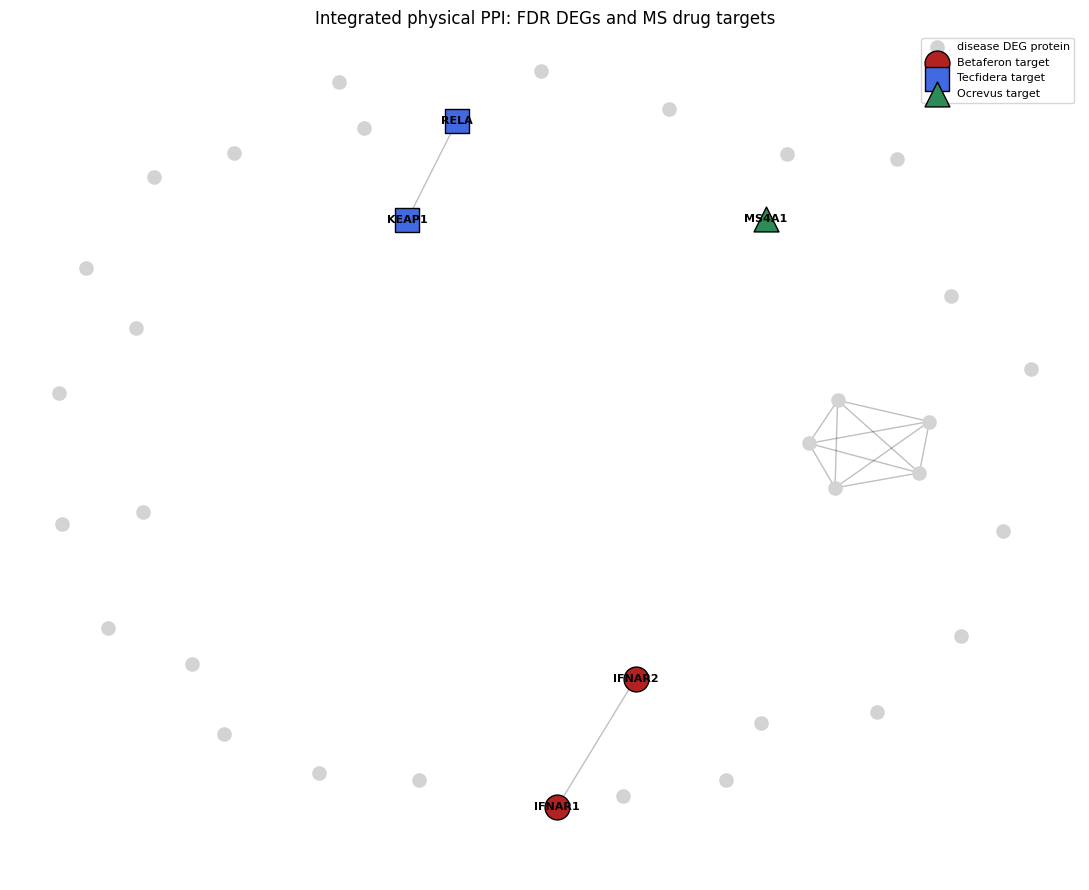

In [47]:
# --- Visualize the EXISTING integrated disease + drug-target physical network (no rebuild) ---
# drug -> its mapped preferredName targets (a target shared by >1 drug is kept for each drug)
_drug_pref = {drug: [pref_int[t] for t in T if t in pref_int and pref_int[t] in Gint]
              for drug, T in drug_targets.items()}
_pos = nx.spring_layout(Gint, seed=42, k=0.6)
fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(Gint, _pos, alpha=0.25, ax=ax)                      # existing STRING edges only
_disease_nodes = [n for n in Gint if node_role.get(n) == 'disease']
nx.draw_networkx_nodes(Gint, _pos, nodelist=_disease_nodes, node_color='lightgrey',
                       node_size=90, label='disease DEG protein', ax=ax)
_overlap_nodes = [n for n in Gint if node_role.get(n) == 'disease-drug overlap']
if _overlap_nodes:
    nx.draw_networkx_nodes(Gint, _pos, nodelist=_overlap_nodes, node_color='gold', node_shape='D',
                           edgecolors='k', node_size=340, label='disease-drug overlap', ax=ax)
_style = {'Betaferon': ('firebrick', 'o'), 'Tecfidera': ('royalblue', 's'), 'Ocrevus': ('seagreen', '^')}
for drug, prefs in _drug_pref.items():
    prefs = [p for p in prefs if p not in set(_overlap_nodes)]
    if not prefs: continue
    col, mk = _style.get(drug, ('purple', 'P'))
    nx.draw_networkx_nodes(Gint, _pos, nodelist=prefs, node_color=col, node_shape=mk,
                           edgecolors='k', node_size=320, label=f'{drug} target', ax=ax)
# label all drug targets (+ overlaps) and any disease node directly adjacent to a target
_target_nodes = set(target_pref)
_adjacent_disease = {v for t in _target_nodes if t in Gint for v in Gint.neighbors(t)
                     if node_role.get(v) == 'disease'}
_lab = {n: n for n in (_target_nodes | set(_overlap_nodes) | _adjacent_disease)}
nx.draw_networkx_labels(Gint, _pos, labels=_lab, font_size=8, font_weight='bold', ax=ax)
ax.set_title('Integrated physical PPI: FDR DEGs and MS drug targets'); ax.legend(scatterpoints=1, fontsize=8, loc='best')
ax.axis('off'); plt.tight_layout(); plt.savefig(NET / 'integrated_disease_drug_network.png', dpi=150); plt.show()
_shared = {t: [d for d, T in drug_targets.items() if t in T] for t in drug_target_all}
_shared = {t: ds for t, ds in _shared.items() if len(ds) > 1}
if _shared:
    print('Targets shared by more than one drug (kept for each in the legend):', _shared)

This integrated-network figure is the STRING **physical** network queried on the union of the
FDR protein-coding DEGs and the DrugBank targets (existing edges only, no artificial connectors). A
target at **distance 0** would indicate a disease-drug overlap (a target that is itself an FDR disease
gene). The distances shown in this integrated-network table are measured from each drug target to the
STRING-mapped FDR disease-gene set. This visualization is **descriptive**; the formal drug-disease
proximity analysis performed later uses the explicitly defined disease modules on the fixed STRING
physical interactome.

In [48]:
# --- Compact drug-target distance summary (from existing neighbors_dist; no recomputation) ---
drug_target_distance_view = neighbors_dist[['drug', 'target', 'role',
                                            'distance_to_FDR_disease_set', 'nearest_disease_gene']].copy()
if int((neighbors_dist['distance_to_FDR_disease_set'] == 0).sum()) == 0:
    print('No DrugBank target is itself an FDR disease-network gene (distance 0 overlap = 0).')
drug_target_distance_view

No DrugBank target is itself an FDR disease-network gene (distance 0 overlap = 0).


,drug,target,role,distance_to_FDR_disease_set,nearest_disease_gene
0,Betaferon,IFNAR1,drug_target,disconnected,None
1,Betaferon,IFNAR2,drug_target,disconnected,None
2,Tecfidera,KEAP1,drug_target,disconnected,None
3,Tecfidera,RELA,drug_target,disconnected,None
4,Ocrevus,MS4A1,drug_target,disconnected,None


In [49]:
# --- Guney et al. drug-disease proximity on a fixed human physical interactome ---
# Reference interactome = STRING v12.0 precomputed 9606 PHYSICAL network (independent of our genes).
# Closest distance d_c(S,T) = mean over drug targets t of the shortest-path (hop) distance to the
# nearest disease-module gene s in S. Significance: a null of 1000 random (S',T') pairs drawn with the
# same degree sequence as S and T. Random sets contain unique nodes (no node is drawn twice within a
# set); each node is matched by exact degree, falling back to the closest available degree if no unused
# exact-degree node remains. A drug is 'close' if z < -2.
import gzip, urllib.request, random
from collections import defaultdict
random.seed(SEED); np.random.seed(SEED)
S12 = 'https://stringdb-downloads.org/download'
links = REF/'9606.protein.physical.links.v12.0.txt.gz'; info = REF/'9606.protein.info.v12.0.txt.gz'
for url, dest in [(f'{S12}/protein.physical.links.v12.0/9606.protein.physical.links.v12.0.txt.gz', links),
                  (f'{S12}/protein.info.v12.0/9606.protein.info.v12.0.txt.gz', info)]:
    if not dest.exists():
        print('downloading', dest.name, '...'); urllib.request.urlretrieve(url, dest)
id2sym = {}
with gzip.open(info,'rt',encoding='utf-8') as fh:
    next(fh)
    for line in fh:
        p=line.rstrip('\n').split('\t'); id2sym[p[0]]=p[1]

def fixed_interactome(min_score):
    Gf = nx.Graph()
    with gzip.open(links,'rt',encoding='utf-8') as fh:
        next(fh)
        for line in fh:
            a,b,s = line.split()
            if int(s) >= min_score:
                sa,sb = id2sym.get(a), id2sym.get(b)
                if sa and sb and sa != sb: Gf.add_edge(sa, sb)
    return Gf.subgraph(max(nx.connected_components(Gf), key=len)).copy()

def _dc(distmap, T):
    v = [distmap[t] for t in T if t in distmap]
    return float(np.mean(v)) if v else np.nan

def proximity(Gf, label, targets, S_in, n_rand=1000):
    S = [g for g in S_in if g in Gf]
    by_deg = defaultdict(list)
    for n in Gf: by_deg[Gf.degree(n)].append(n)
    degs = sorted(by_deg)
    fb = [0]; tot = [0]
    def match(nodes, used):
        out = []
        for n in nodes:
            tot[0] += 1
            d = Gf.degree(n)
            pool = [p for p in by_deg.get(d, ()) if p not in used]
            if not pool:                              # closest available degree with an unused node
                fb[0] += 1
                for dd in sorted(degs, key=lambda x: abs(x - d)):
                    pool = [p for p in by_deg[dd] if p not in used]
                    if pool: break
            pick = random.choice(pool); used.add(pick); out.append(pick)
        return out
    # algorithmic invariants: random sets keep their size and contain unique nodes
    _u = set(); _Sr = match(S, _u)
    assert len(_Sr) == len(S) and len(set(_Sr)) == len(_Sr)
    _Tsets = [[t for t in T if t in Gf] for T in targets.values()]
    _T0 = next((t for t in _Tsets if t), [])
    if _T0:
        _Tr = match(_T0, set(_Sr)); assert len(_Tr) == len(_T0) and len(set(_Tr)) == len(_Tr)
    dmap_obs = nx.multi_source_dijkstra_path_length(Gf, S)
    obs = {dr: [t for t in T if t in Gf] for dr, T in targets.items()}
    d_obs = {dr: _dc(dmap_obs, Tm) for dr, Tm in obs.items()}
    NULL = {dr: [] for dr in targets}
    for _ in range(n_rand):
        used = set(); S_rand = match(S, used)
        dmapS = nx.multi_source_dijkstra_path_length(Gf, set(S_rand))
        for dr, Tm in obs.items():
            if Tm: NULL[dr].append(_dc(dmapS, match(Tm, set(S_rand))))
    Smod = set(S); rows = []
    for dr, T in targets.items():
        Tm = obs[dr]; arr = np.array([x for x in NULL[dr] if np.isfinite(x)])
        overlap = sorted(set(Tm) & Smod)
        if len(Tm) == 0 or len(arr) < 50:
            rows.append({'drug': dr, 'targets': len(T), 'mapped': len(Tm), 'in_module': ';'.join(overlap) or '-',
                         'd_closest': None, 'null_mean': None, 'null_sd': None, 'z': None, 'status': 'NA (coverage)'})
            continue
        z = (d_obs[dr] - arr.mean()) / arr.std() if arr.std() > 0 else np.nan
        stt = ('closer than chance (z<-2)' if z < -2 else 'more distant than chance (z>+2)' if z > 2 else 'not significant')
        rows.append({'drug': dr, 'targets': len(T), 'mapped': len(Tm), 'in_module': ';'.join(overlap) or '-',
                     'd_closest': round(d_obs[dr], 3), 'null_mean': round(arr.mean(), 3),
                     'null_sd': round(arr.std(), 3), 'z': round(z, 2), 'status': stt})
    df = pd.DataFrame(rows); df['network'] = label
    print(f'[{label}] {fb[0]}/{tot[0]} sampled nodes used a closest-degree fallback (no unused exact-degree node).')
    return df

Gfix = fixed_interactome(400)
print(f'Fixed STRING physical interactome (score>=400, LCC): {Gfix.number_of_nodes()} nodes, {Gfix.number_of_edges()} edges')
_Sp = [g for g in disease_module_primary if g in Gfix]
_Sr = [g for g in disease_module if g in Gfix]
print(f'Primary disease-module coverage on the interactome: {len(_Sp)}/{len(disease_module_primary)} mapped -> {_Sp}')
print(f'Relaxed (sensitivity) module coverage: {len(_Sr)}/{len(disease_module)} mapped.')

prox = pd.concat([
    proximity(Gfix, 'PRIMARY: DrugBank targets vs primary DEG module (score>=400)', drug_targets, disease_module_primary),
    proximity(fixed_interactome(700), 'sensitivity: DrugBank targets, score>=700', drug_targets, disease_module_primary),
    proximity(Gfix, 'sensitivity: DrugBank targets vs relaxed module', drug_targets, disease_module),
], ignore_index=True)
prox.to_csv(NET/'drug_proximity.csv', index=False)
prox

Fixed STRING physical interactome (score>=400, LCC): 15640 nodes, 210570 edges
Primary disease-module coverage on the interactome: 5/5 mapped -> ['H2AC12', 'H2AC13', 'H2AC18', 'H2BC17', 'H2BC5']
Relaxed (sensitivity) module coverage: 15/15 mapped.


[PRIMARY: DrugBank targets vs primary DEG module (score>=400)] 0/10007 sampled nodes used a closest-degree fallback (no unused exact-degree node).


[sensitivity: DrugBank targets, score>=700] 0/10007 sampled nodes used a closest-degree fallback (no unused exact-degree node).


[sensitivity: DrugBank targets vs relaxed module] 0/20017 sampled nodes used a closest-degree fallback (no unused exact-degree node).


,drug,targets,mapped,in_module,d_closest,null_mean,null_sd,z,status,network
0,Betaferon,2,2,-,3.0,2.222,0.417,1.87,not significant,PRIMARY: DrugBank targets vs primary DEG modul...
1,Tecfidera,2,2,-,2.0,1.864,0.360,0.38,not significant,PRIMARY: DrugBank targets vs primary DEG modul...
2,Ocrevus,1,1,-,3.0,2.697,0.593,0.51,not significant,PRIMARY: DrugBank targets vs primary DEG modul...
3,Betaferon,2,2,-,3.0,2.756,0.531,0.46,not significant,"sensitivity: DrugBank targets, score>=700"
4,Tecfidera,2,2,-,2.5,2.188,0.414,0.76,not significant,"sensitivity: DrugBank targets, score>=700"
5,Ocrevus,1,1,-,4.0,3.803,1.027,0.19,not significant,"sensitivity: DrugBank targets, score>=700"
6,Betaferon,2,2,-,2.0,2.039,0.343,-0.11,not significant,sensitivity: DrugBank targets vs relaxed module
7,Tecfidera,2,2,-,2.0,1.804,0.302,0.65,not significant,sensitivity: DrugBank targets vs relaxed module
8,Ocrevus,1,1,-,2.0,2.551,0.556,-0.99,not significant,sensitivity: DrugBank targets vs relaxed module


In [50]:
# --- Disease-drug overlap: where do the drug targets fall in the relaxed sensitivity network? ---
# Map each DrugBank drug target onto the relaxed sensitivity network (G) and its Louvain communities.
rows=[]
for drug, T in drug_targets.items():
    for t in T:
        in_net = t in G
        rows.append({'drug':drug,'target':t,'in_relaxed_network':in_net,
                     'community': (partition.get(t) if in_net else None),
                     'is_disease_module': t in disease_module})
overlap = pd.DataFrame(rows)
overlap.to_csv(NET/'disease_drug_overlap.csv', index=False)
n_in = int(overlap['in_relaxed_network'].sum())
print(f'Drug targets present in the relaxed sensitivity network: {n_in} of {len(overlap)}')
overlap

Drug targets present in the relaxed sensitivity network: 0 of 5


,drug,target,in_relaxed_network,community,is_disease_module
0,Betaferon,IFNAR1,False,None,False
1,Betaferon,IFNAR2,False,None,False
2,Tecfidera,KEAP1,False,None,False
3,Tecfidera,RELA,False,None,False
4,Ocrevus,MS4A1,False,None,False


In [51]:
# --- Which communities are reached by each drug's targets (on the fixed interactome) ---
# For each mapped target we find the nearest disease-module node on the FIXED STRING interactome
# and report the Louvain community of that node (community assignments come from the relaxed network).
S_fix = [g for g in disease_module if g in Gfix]
_dmaps = {s: nx.single_source_shortest_path_length(Gfix, s) for s in S_fix}   # dist from each module node
# short label per community: its 3 highest-centrality member genes
_lab = {}
for _cm in sorted(set(partition.values())):
    _members = [n for n,cc in partition.items() if cc==_cm and n in cent.index]
    _lab[_cm] = ', '.join(cent.loc[_members,'consensus_centrality_rank'].sort_values(ascending=False).head(3).index)
rows=[]
for drug, T in drug_targets.items():
    for t in T:
        if t not in Gfix:
            rows.append({'drug':drug,'target':t,'nearest_disease_node':None,'distance':None,
                         'disease_community':None,'community_top_genes':None}); continue
        dist, nearest = min(((_dmaps[s].get(t, np.inf), s) for s in S_fix), key=lambda x: x[0])
        cm = partition.get(nearest)
        rows.append({'drug':drug,'target':t,'nearest_disease_node':nearest,
                     'distance':(int(dist) if np.isfinite(dist) else None),
                     'disease_community':cm,'community_top_genes':_lab.get(cm,'')})
drug_comm = pd.DataFrame(rows); drug_comm.to_csv(NET/'drug_target_communities.csv', index=False)
print('Nearest disease-module node and its community, per drug target (fixed interactome):')
print(drug_comm.to_string(index=False))
# which communities each drug reaches most
print('\nCommunities reached by each drug (via nearest disease-module node):')
for drug in drug_targets:
    cs = drug_comm.loc[(drug_comm.drug==drug) & drug_comm.disease_community.notna(),'disease_community']
    print(f'  {drug}: ' + (', '.join(f'community {int(c)}' for c in sorted(cs.unique())) if len(cs) else 'no mapped target reaches the module'))

# Extended drug-target path network: DrugBank targets + disease module + shortest-path connectors (Cytoscape/GraphML)
Gpaths = nx.Graph(); role={}
for g in S_fix: role[g]='disease_module'
for drug,T in drug_targets.items():
    for t in T:
        if t not in Gfix: continue
        role[t]='drug_target'
        _,nearest = min(((_dmaps[s].get(t,np.inf), s) for s in S_fix), key=lambda x:x[0])
        try:
            path = nx.shortest_path(Gfix, t, nearest)
            nx.add_path(Gpaths, path)
            for n in path: role.setdefault(n,'connector')
        except nx.NetworkXNoPath:
            Gpaths.add_node(t)
for n in Gpaths.nodes(): Gpaths.nodes[n]['role']=role.get(n,'connector')
nx.write_graphml(Gpaths, NET/'drug_target_paths.graphml')
print(f'\nExtended drug-target path network (drug_target_paths.graphml): {Gpaths.number_of_nodes()} nodes, '
      f'{Gpaths.number_of_edges()} edges - mapped DrugBank targets, disease-module nodes and shortest-path connectors.')
drug_comm

Nearest disease-module node and its community, per drug target (fixed interactome):
     drug target nearest_disease_node  distance  disease_community  community_top_genes
Betaferon IFNAR1                PLCG2         2                  2    PLCG2, LYN, KLRK1
Betaferon IFNAR2                PLCG2         2                  2    PLCG2, LYN, KLRK1
Tecfidera  KEAP1                PLCG2         2                  2    PLCG2, LYN, KLRK1
Tecfidera   RELA                CXCR1         2                  5 CXCR1, CXCR2, CX3CR1
  Ocrevus  MS4A1                PLCG2         2                  2    PLCG2, LYN, KLRK1

Communities reached by each drug (via nearest disease-module node):
  Betaferon: community 2
  Tecfidera: community 2, community 5
  Ocrevus: community 2



Extended drug-target path network (drug_target_paths.graphml): 12 nodes, 10 edges - mapped DrugBank targets, disease-module nodes and shortest-path connectors.


,drug,target,nearest_disease_node,distance,disease_community,community_top_genes
0,Betaferon,IFNAR1,PLCG2,2,2,"PLCG2, LYN, KLRK1"
1,Betaferon,IFNAR2,PLCG2,2,2,"PLCG2, LYN, KLRK1"
2,Tecfidera,KEAP1,PLCG2,2,2,"PLCG2, LYN, KLRK1"
3,Tecfidera,RELA,CXCR1,2,5,"CXCR1, CXCR2, CX3CR1"
4,Ocrevus,MS4A1,PLCG2,2,2,"PLCG2, LYN, KLRK1"


In [52]:
# --- Cytoscape node attribute table + GraphML with attributes (built after centrality/communities) ---
res_sym = res.dropna(subset=['symbol']).drop_duplicates('symbol').set_index('symbol')
tgt2drug = {}
for _d, _ts in drug_targets.items():
    for _t in _ts: tgt2drug.setdefault(_t, []).append(_d)
rows = []
for g in G.nodes():
    inC = g in cent.index; inR = g in res_sym.index
    rows.append({'gene': g,
        'log2FC': round(float(res_sym.loc[g,'log2FoldChange']),3) if inR else np.nan,
        'padj': (f"{res_sym.loc[g,'padj']:.3g}" if inR and pd.notna(res_sym.loc[g,'padj']) else 'NA'),
        'degree': int(cent.loc[g,'degree']) if inC else 0,
        'betweenness': round(float(cent.loc[g,'betweenness']),4) if inC else 0.0,
        'closeness': round(float(cent.loc[g,'closeness']),4) if inC else 0.0,
        'eigenvector': round(float(cent.loc[g,'eigenvector']),4) if inC else 0.0,
        'consensus_centrality_rank': round(float(cent.loc[g,'consensus_centrality_rank']),4) if inC else 0.0,
        'community': int(partition.get(g,-1)),
        'is_disease_module': bool(g in disease_module),
        'drug_target_for': ';'.join(tgt2drug.get(g,[]))})
node_info = pd.DataFrame(rows)
node_info.to_csv(NET/'node_info.tsv', sep='\t', index=False)
# Export the final GraphML with centrality, community and drug-target attributes
attrs = ['log2FC','padj','degree','betweenness','closeness','eigenvector','consensus_centrality_rank',
         'community','is_disease_module','drug_target_for']
info_by_gene = node_info.set_index('gene')
for n in G.nodes():
    for a in attrs:
        v = info_by_gene.loc[n, a]
        if isinstance(v, str):
            G.nodes[n][a] = v
        elif pd.isna(v):
            continue                                   # omit unknown value instead of fabricating one
        else:
            G.nodes[n][a] = v.item() if hasattr(v, 'item') else v
nx.write_graphml(G, NET/'ppi_network.graphml')
print('node_info.tsv:', node_info.shape, '- GraphML rewritten with node attributes for Cytoscape')
node_info.head()

node_info.tsv: (39, 11) - GraphML rewritten with node attributes for Cytoscape


,gene,log2FC,padj,degree,betweenness,closeness,eigenvector,consensus_centrality_rank,community,is_disease_module,drug_target_for
0,ADRA1A,-0.645,0.718,1,0.0000,0.2032,0.0885,0.3269,5,False,
1,CADM1,-1.221,0.101,1,0.0000,0.2209,0.0066,0.2788,4,False,
2,CCL3L1,NaN,NA,3,0.0005,0.2452,0.2713,0.6186,5,True,
3,CCL4,-1.475,0.413,3,0.0005,0.2452,0.2713,0.6186,5,True,
4,CD151,-0.600,0.136,1,0.0000,0.1818,0.0002,0.1090,1,False,


### Part 2 - discussion

**Primary PPI (assignment-compliant).** The primary protein-protein interaction network is built from
the exact Part-1 DEG set (FDR padj<0.05). Only protein-coding DEGs are eligible for STRING physical
mapping; non-protein-coding DEGs are reported as not eligible for PPI mapping, and STRING-unmapped
protein-coding DEGs are reported separately. All STRING-mapped proteins are retained, including
degree-zero isolates. As the funnel in the network cell shows, at 4-vs-4 this primary network is
small and fragmented: only a small connected cluster carries physical edges while most DEGs are
isolated. The primary FDR DEG network is sparse and fragmented, consistent with the limited number of DEGs identified in the 4-vs-4 analysis.
Degree and betweenness are computed on the full primary PPI, while closeness, eigenvector centrality, and Louvain community detection are evaluated on its largest connected component; the primary disease
module is drawn only from its connected nodes (fewer than the nominal 10-15), and no genes are
borrowed from the relaxed network to enlarge it.

**Secondary relaxed network (sensitivity only).** Because the primary FDR network is too sparse for
informative topology, a relaxed network (nominal p<0.05 and |log2FC|>=0.58,
protein-coding) is analysed as a clearly separated **sensitivity** analysis. Its top-centrality nodes
are chemokine and NK/cytotoxic genes (`CXCR1`, `CXCR2`, `CX3CR1`, `FCGR3A`, `LYN`, `PLCG2`, `KLRK1`,
`FASLG`, ...), consistent with the interferon/IL-8/NK axis that GSEA finds down-regulated in MS. It is
a sensitivity analysis and does not replace the primary FDR-DEG result.

**Centrality.** For the relaxed sensitivity network, degree, betweenness, closeness and eigenvector
centrality are summarized by their mean percentile rank (`consensus_centrality_rank`, a custom summary
and not a standard centrality metric) to obtain a combined ranking of the top 15 nodes; the individual
centrality values are reported separately. High degree indicates a hub, high betweenness a bottleneck,
and high closeness/eigenvector a globally central node.

**Communities and their relationship to Part-1 enrichment.** Communities are detected with **Louvain**
(the modularity method covered in class). Louvain was selected because the STRING physical PPI is an
undirected weighted network and the method can use edge confidence while efficiently identifying modules
through modularity maximization, which makes it appropriate for detecting densely interconnected
functional modules in the present PPI; a known limitation of modularity-based methods is the resolution
limit, which may merge small communities. Relating the
relaxed-network communities to the Part-1 enrichment (per-community enrichment cell) shows that the
chemokine/GPCR-signalling community maps onto the interferon/IL-8/NK program GSEA finds
down-regulated in MS, while the TNF/NF-kB and cell-adhesion communities correspond to immune-signalling
terms. The clusters are therefore coherent with, not independent of, the Part-1 pathway results.

**Drug-disease proximity (Guney et al.).** Proximity is computed on a fixed STRING v12.0 human
physical interactome, independent of our genes. The drug modules are the DrugBank-classified targets
(Betaferon: IFNAR1, IFNAR2; Tecfidera: KEAP1, RELA; Ocrevus: MS4A1). The closest distance dc is compared to a null of 1000 random
(S', T') pairs drawn with the same degree sequence as S and T (exact-degree matching; a
nearest-degree fallback is available but was not required for these sets). As the proximity
table shows, none of the three drugs is significantly close or distant from the disease module (all
|z|<2), and no drug target lies inside the module (overlap = distance 0). At 4-vs-4 the small module
does not provide enough signal to position these drugs by network proximity. Ocrevus is represented by
a single mapped target, so its closest-path distance is based on one target protein.

**Which communities do the drug targets reach?** For each mapped target we report its nearest node in
the relaxed disease module and that node's community (drug-community cell; `drug_target_communities.csv`).
This is descriptive network-topological evidence only - given the small module and the non-significant
proximity - not proof of a therapeutic mechanism.

## Limitations

- The study uses four MS and four HC samples, so statistical power is limited compared with the
  original paper.
- The primary FDR-DEG physical PPI is sparse and fragmented; degree and betweenness are evaluated on the full graph,
  whereas path- and spectral-based centralities and Louvain communities are evaluated on its largest
  connected component, and the disease module is small. The relaxed network is used only as a sensitivity analysis.
- Salmon uses a transcriptome-only index (no genome decoy) because of memory constraints; the mapping
  rate is therefore lower than a genome-alignment pipeline, and mapping statistics are not directly
  comparable with the paper (STAR followed by RSEM).
- Drug-disease proximity is inconclusive at this sample size rather than positive.